# Install & Import Library

In [57]:
# Install & Import Library
# !pip install kaggle statsmodels tensorflow pandas numpy matplotlib seaborn scikit-learn

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow import keras

print("TensorFlow version:", tf.__version__)
print("Semua library berhasil diimport!")


TensorFlow version: 2.20.0
Semua library berhasil diimport!


# Import Data

In [58]:
csv_url = 'https://drive.google.com/uc?export=download&id=1hpsqSpfjdqIZWqwd259klQSeaNSe5Trr'

df = pd.read_csv(csv_url)

# Parse datetime (aman untuk format campuran)
df['Date'] = pd.to_datetime(
    df['Date'],
    format='mixed',
    errors='coerce'
)

# Cek apakah ada tanggal gagal diparse
print("Jumlah NaT:", df['Date'].isna().sum())

# Hapus baris yang gagal diparse (jika ada)
df = df.dropna(subset=['Date'])

# Urutkan waktu
df = df.sort_values('Date')

# Set index datetime
df = df.set_index('Date')

# Informasi dataset
print(f"\nShape dataset: {df.shape}")
print(f"Rentang waktu: {df.index.min()} s/d {df.index.max()}")

print("\nMissing Values:")
print(df.isnull().sum())

print("\nInfo Dataset:")
print(df.info())

display(df.head())

Jumlah NaT: 0

Shape dataset: (53150, 6)
Rentang waktu: 2017-09-21 09:00:00 s/d 2023-10-19 23:00:00

Missing Values:
Close          0
Volume USDT    0
RSI            0
MACD_Hist      0
ATR            0
KAMAO          0
dtype: int64

Info Dataset:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 53150 entries, 2017-09-21 09:00:00 to 2023-10-19 23:00:00
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Close        53150 non-null  float64
 1   Volume USDT  53150 non-null  float64
 2   RSI          53150 non-null  float64
 3   MACD_Hist    53150 non-null  float64
 4   ATR          53150 non-null  float64
 5   KAMAO        53150 non-null  float64
dtypes: float64(6)
memory usage: 2.8 MB
None


,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO
Date,,,,,,
2017-09-21 09:00:00,3860.00,74434.891166,49.192454,-48.279697,88.054720,2.495591
2017-09-21 10:00:00,3871.48,44687.318944,49.233202,-47.780476,87.996283,2.616710
2017-09-21 11:00:00,3864.95,80546.171672,49.210685,-47.308061,87.897128,2.532239
2017-09-21 12:00:00,3858.08,90331.531390,49.186948,-46.863233,87.720856,2.447245
2017-09-21 13:00:00,3856.67,103405.818040,49.182064,-46.425379,87.578086,2.424654


# Eksplorasi Data Analysis (EDA) Awal

In [59]:
# Eksplorasi Data Analysis (EDA)

print("=" * 60)
print("EKSPLORASI DATA ANALYSIS")
print("=" * 60)

# Cek missing values
print("\nMissing values per kolom:")
print(df.isnull().sum())

# Cek duplikat
print(f"\nJumlah duplikat: {df.duplicated().sum()}")

# Basic statistics
print("\nStatistik Deskriptif:")
df.describe()

EKSPLORASI DATA ANALYSIS

Missing values per kolom:
Close          0
Volume USDT    0
RSI            0
MACD_Hist      0
ATR            0
KAMAO          0
dtype: int64

Jumlah duplikat: 0

Statistik Deskriptif:


,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO
count,53150.000000,5.315000e+04,53150.000000,53150.000000,53150.000000,53150.000000
mean,20595.357333,6.919215e+07,50.403605,0.528272,221.733334,0.229762
std,15822.296994,1.059041e+08,3.210682,353.293188,208.401440,5.168655
min,3172.050000,0.000000e+00,35.178834,-1885.690630,17.436266,-31.767152
25%,7976.915000,1.012558e+07,48.294197,-115.601600,72.702488,-2.717470
50%,13878.095000,2.766119e+07,50.038483,10.154419,128.787616,-0.032747
75%,29646.720000,8.944278e+07,52.406274,122.367509,325.616826,3.162442
max,68633.690000,3.005634e+09,64.657108,1430.405758,1004.531407,39.740297


# Pemilihan Fitur

In [60]:
# Pemilihan Fitur

# Fitur yang dipilih (>= 3 fitur sesuai kriteria)
FEATURES = ['Close', 'Volume USDT', 'RSI', 'MACD_Hist', 'ATR', 'KAMAO']
TARGET = 'Close'

df_selected = df[FEATURES].copy()

print(f"Fitur yang digunakan ({len(FEATURES)} fitur):")
for i, f in enumerate(FEATURES, 1):
    print(f"  {i}. {f}")

Fitur yang digunakan (6 fitur):
  1. Close
  2. Volume USDT
  3. RSI
  4. MACD_Hist
  5. ATR
  6. KAMAO


# Feature Engineering - Rolling Statistics

In [61]:
# Feature Engineering - Rolling Statistics (ADVANCED)

print("\n" + "=" * 60)
print("FEATURE ENGINEERING - ROLLING STATISTICS (ADVANCED)")
print("=" * 60)

# Rolling Mean (Moving Average) - window 24 jam
df_selected['Close_MA24'] = df_selected['Close'].rolling(window=24, min_periods=1).mean()

# Rolling Standard Deviation - window 24 jam (volatilitas)
df_selected['Close_STD24'] = df_selected['Close'].rolling(window=24, min_periods=1).std().fillna(0)

# Rolling Min & Max (Bollinger Band-like)
df_selected['Close_Min24'] = df_selected['Close'].rolling(window=24, min_periods=1).min()
df_selected['Close_Max24'] = df_selected['Close'].rolling(window=24, min_periods=1).max()

# Price Rate of Change (ROC)
df_selected['Close_ROC'] = df_selected['Close'].pct_change(periods=1).fillna(0)

print("Rolling Features yang dibuat:")
print("  1. Close_MA24   - Moving Average 24 jam")
print("  2. Close_STD24  - Rolling Std Deviation 24 jam (Volatilitas)")
print("  3. Close_Min24  - Rolling Minimum 24 jam")
print("  4. Close_Max24  - Rolling Maximum 24 jam")
print("  5. Close_ROC    - Rate of Change 1-step")

# Update daftar fitur
FEATURES_EXTENDED = FEATURES + ['Close_MA24', 'Close_STD24', 'Close_Min24', 'Close_Max24', 'Close_ROC']

df_selected = df_selected.dropna().reset_index(drop=True)
print(f"\nShape setelah feature engineering: {df_selected.shape}")
print(f"Total fitur: {len(FEATURES_EXTENDED)}")
df_selected.head()


FEATURE ENGINEERING - ROLLING STATISTICS (ADVANCED)
Rolling Features yang dibuat:
  1. Close_MA24   - Moving Average 24 jam
  2. Close_STD24  - Rolling Std Deviation 24 jam (Volatilitas)
  3. Close_Min24  - Rolling Minimum 24 jam
  4. Close_Max24  - Rolling Maximum 24 jam
  5. Close_ROC    - Rate of Change 1-step

Shape setelah feature engineering: (53150, 11)
Total fitur: 11


,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO,Close_MA24,Close_STD24,Close_Min24,Close_Max24,Close_ROC
0,3860.00,74434.891166,49.192454,-48.279697,88.054720,2.495591,3860.000000,0.000000,3860.00,3860.00,0.000000
1,3871.48,44687.318944,49.233202,-47.780476,87.996283,2.616710,3865.740000,8.117586,3860.00,3871.48,0.002974
2,3864.95,80546.171672,49.210685,-47.308061,87.897128,2.532239,3865.476667,5.758093,3860.00,3871.48,-0.001687
3,3858.08,90331.531390,49.186948,-46.863233,87.720856,2.447245,3863.627500,5.981758,3858.08,3871.48,-0.001778
4,3856.67,103405.818040,49.182064,-46.425379,87.578086,2.424654,3862.236000,6.042965,3856.67,3871.48,-0.000365


# Eksplorasi Data Analysis (EDA)

## Visualisasi Data Close Price

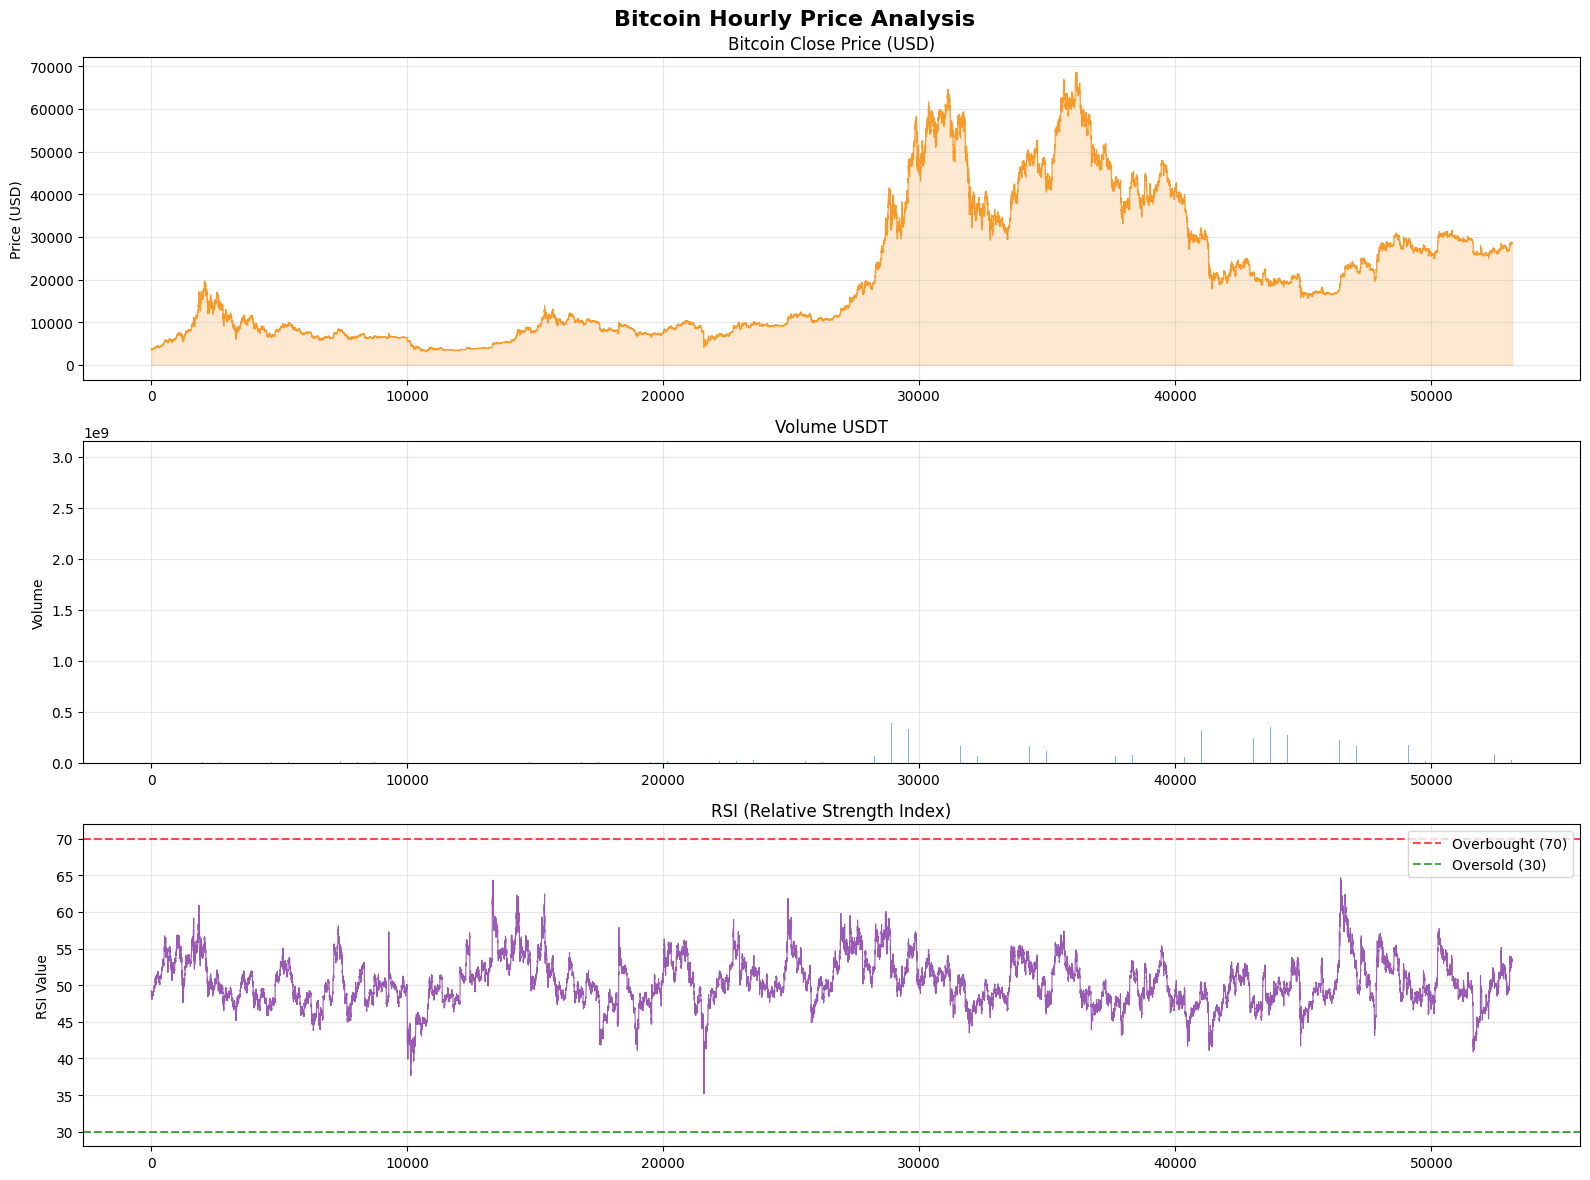

Plot EDA berhasil ditampilkan!


In [62]:
# Visualisasi Data Close Price

fig, axes = plt.subplots(3, 1, figsize=(16, 12))
fig.suptitle('Bitcoin Hourly Price Analysis', fontsize=16, fontweight='bold')

# Plot Close Price
axes[0].plot(df_selected.index, df_selected['Close'], color='#F7931A', linewidth=0.8, alpha=0.9)
axes[0].fill_between(df_selected.index, df_selected['Close'], alpha=0.2, color='#F7931A')
axes[0].set_title('Bitcoin Close Price (USD)', fontsize=12)
axes[0].set_ylabel('Price (USD)')
axes[0].grid(True, alpha=0.3)

# Plot Volume USDT
axes[1].bar(df_selected.index, df_selected['Volume USDT'], color='#4A90D9', alpha=0.7, width=0.03)
axes[1].set_title('Volume USDT', fontsize=12)
axes[1].set_ylabel('Volume')
axes[1].grid(True, alpha=0.3)

# Plot RSI
axes[2].plot(df_selected.index, df_selected['RSI'], color='#9B59B6', linewidth=0.8)
axes[2].axhline(y=70, color='red', linestyle='--', alpha=0.7, label='Overbought (70)')
axes[2].axhline(y=30, color='green', linestyle='--', alpha=0.7, label='Oversold (30)')
axes[2].set_title('RSI (Relative Strength Index)', fontsize=12)
axes[2].set_ylabel('RSI Value')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    '/content/bitcoin_eda.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print("Plot EDA berhasil ditampilkan!")

## Heatmap Korelasi Antar Fitur

HEATMAP KORELASI ANTAR FITUR


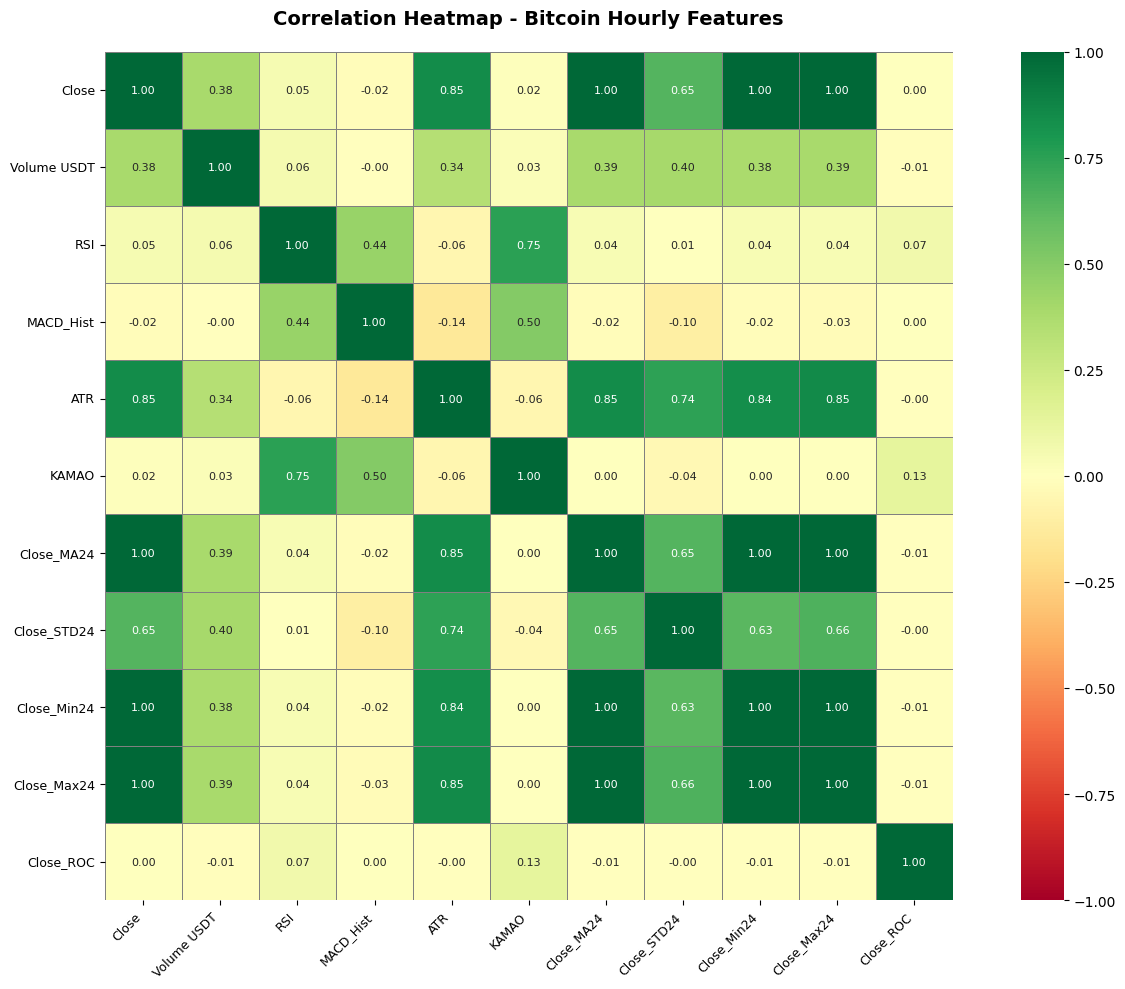


Korelasi fitur terhadap Close Price (sorted):
  Close_MA24          : +0.9994 ███████████████████
  Close_Min24         : +0.9992 ███████████████████
  Close_Max24         : +0.9992 ███████████████████
  ATR                 : +0.8473 ████████████████
  Close_STD24         : +0.6453 ████████████
  Volume USDT         : +0.3840 ███████
  RSI                 : +0.0477 
  KAMAO               : +0.0152 
  Close_ROC           : +0.0022 
  MACD_Hist           : -0.0207 


In [63]:
# Heatmap Korelasi Antar Fitur (KRITERIA 1)

print("=" * 60)
print("HEATMAP KORELASI ANTAR FITUR")
print("=" * 60)

# Hitung korelasi
corr_matrix = df_selected[FEATURES_EXTENDED].corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # Sembunyikan segitiga atas (opsional)

heatmap = sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='gray',
    annot_kws={'size': 8},
    ax=ax,
    square=True
)

ax.set_title('Correlation Heatmap - Bitcoin Hourly Features',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Analisis korelasi dengan Close
print("\nKorelasi fitur terhadap Close Price (sorted):")
corr_with_close = corr_matrix['Close'].drop('Close').sort_values(ascending=False)
for feat, val in corr_with_close.items():
    bar = '█' * int(abs(val) * 20)
    sign = '+' if val > 0 else '-'
    print(f"  {feat:20s}: {sign}{abs(val):.4f} {bar}")

In [64]:
# Hapus fitur yang terlalu berkorelasi tinggi
df_selected = df_selected.drop(
    columns=[
        'Close_MA24',
        'Close_Min24',
        'Close_Max24'
    ]
)

In [65]:
df_selected.head()

,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO,Close_STD24,Close_ROC
0,3860.00,74434.891166,49.192454,-48.279697,88.054720,2.495591,0.000000,0.000000
1,3871.48,44687.318944,49.233202,-47.780476,87.996283,2.616710,8.117586,0.002974
2,3864.95,80546.171672,49.210685,-47.308061,87.897128,2.532239,5.758093,-0.001687
3,3858.08,90331.531390,49.186948,-46.863233,87.720856,2.447245,5.981758,-0.001778
4,3856.67,103405.818040,49.182064,-46.425379,87.578086,2.424654,6.042965,-0.000365


## Dekomposisi Time Series


ANALISIS DEKOMPOSISI TIME SERIES (ADVANCED)


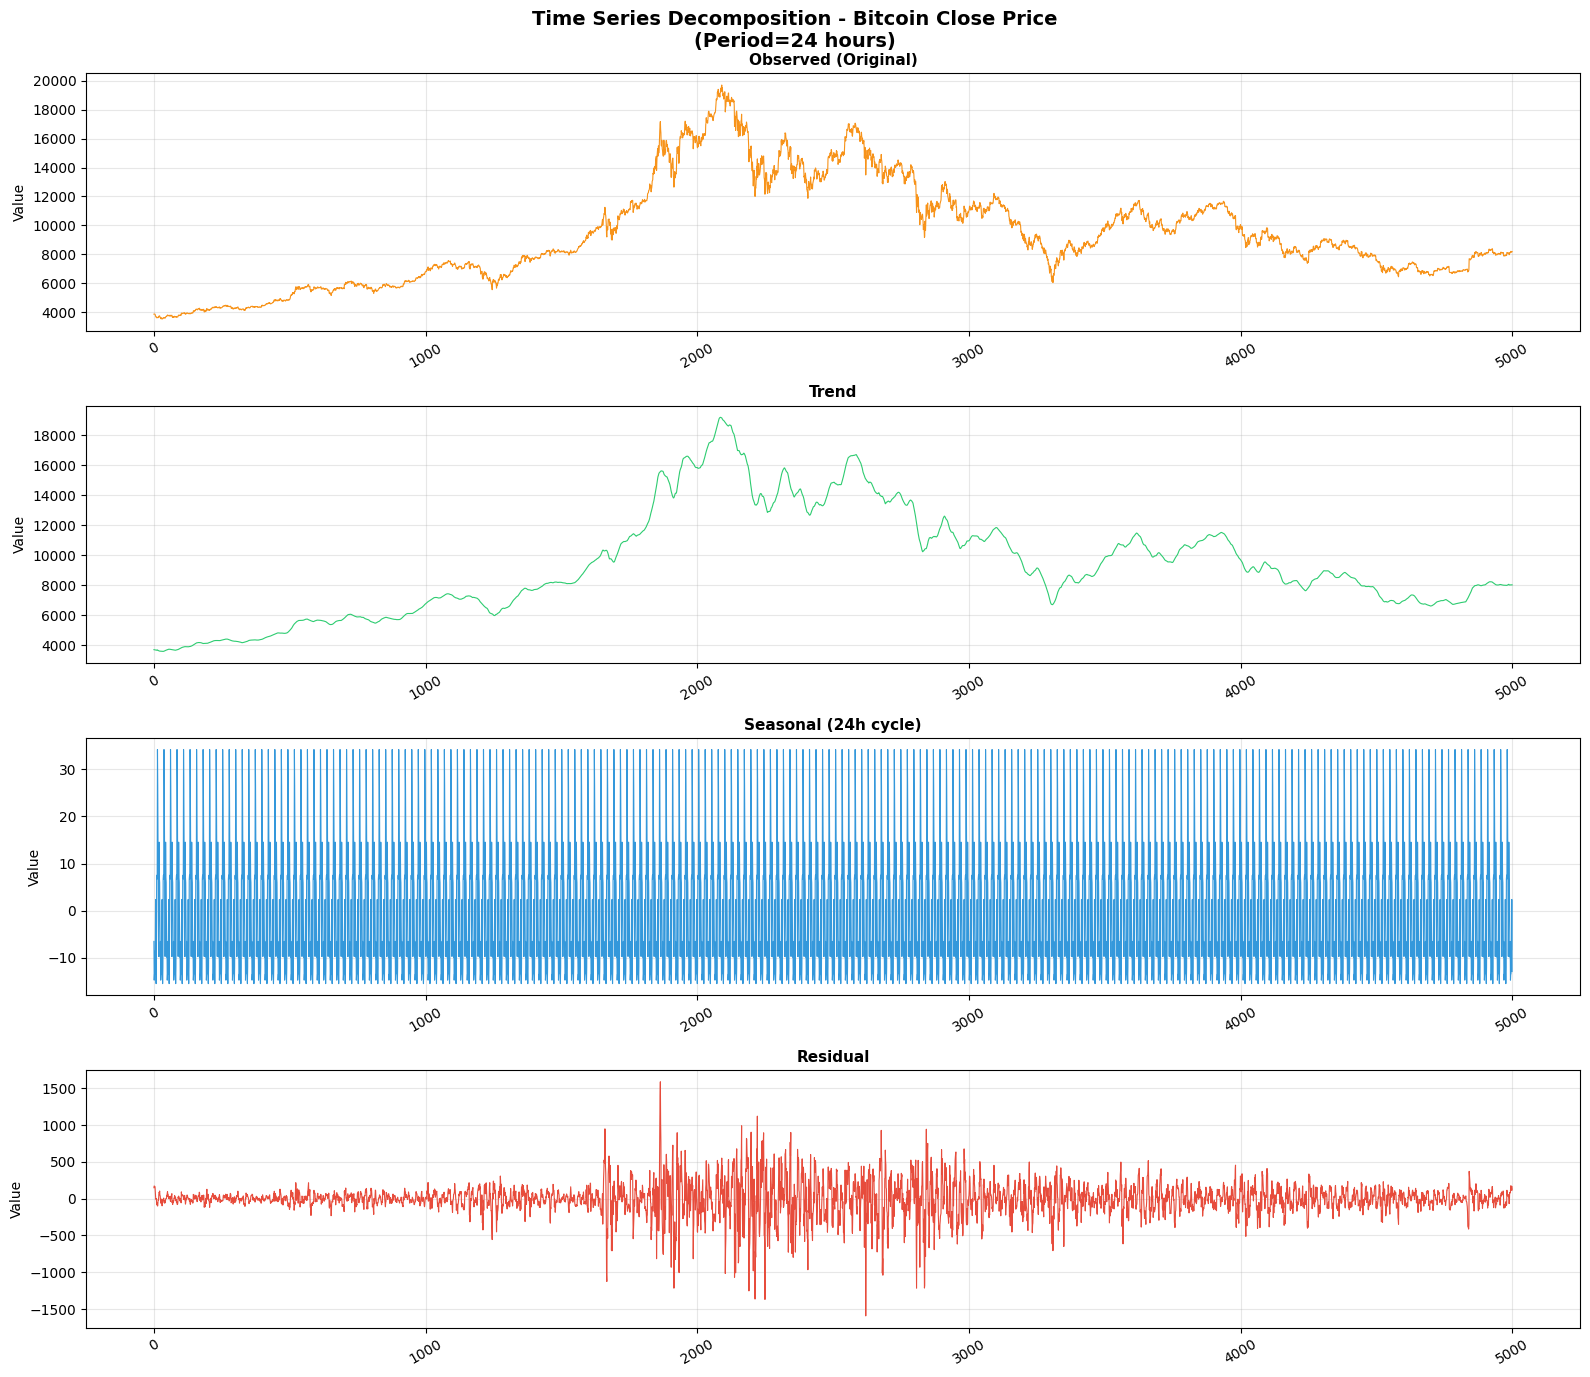

Dekomposisi berhasil!
  - Observed: Data asli Bitcoin Close Price
  - Trend: Kecenderungan jangka panjang
  - Seasonal: Pola berulang setiap 24 jam
  - Residual: Noise / sisa yang tidak bisa dijelaskan


In [66]:
# Dekomposisi Time Series

print("\n" + "=" * 60)
print("ANALISIS DEKOMPOSISI TIME SERIES (ADVANCED)")
print("=" * 60)

# Gunakan subset data untuk decompose (lebih efisien)
# Period = 24 (hourly, 1 hari = 24 jam)
DECOMPOSE_PERIOD = 24

# Ambil subset agar tidak terlalu lambat
close_series = df_selected['Close'].iloc[:5000]

decomposition = seasonal_decompose(
    close_series,
    model='additive',
    period=DECOMPOSE_PERIOD,
    extrapolate_trend='freq'
)

# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(16, 14))
fig.suptitle('Time Series Decomposition - Bitcoin Close Price\n(Period=24 hours)',
             fontsize=14, fontweight='bold')

components = [
    (decomposition.observed,  'Observed (Original)', '#F7931A'),
    (decomposition.trend,     'Trend', '#2ECC71'),
    (decomposition.seasonal,  'Seasonal (24h cycle)', '#3498DB'),
    (decomposition.resid,     'Residual', '#E74C3C'),
]

for ax, (data, title, color) in zip(axes, components):
    ax.plot(data.index, data.values, color=color, linewidth=0.8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Value')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(
    '/content/decomposition.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

print("Dekomposisi berhasil!")
print(f"  - Observed: Data asli Bitcoin Close Price")
print(f"  - Trend: Kecenderungan jangka panjang")
print(f"  - Seasonal: Pola berulang setiap {DECOMPOSE_PERIOD} jam")
print(f"  - Residual: Noise / sisa yang tidak bisa dijelaskan")


# Uji ACF & PACF untuk Menentukan Window Size



UJI ACF & PACF - PENENTUAN WINDOW SIZE (ADVANCED)


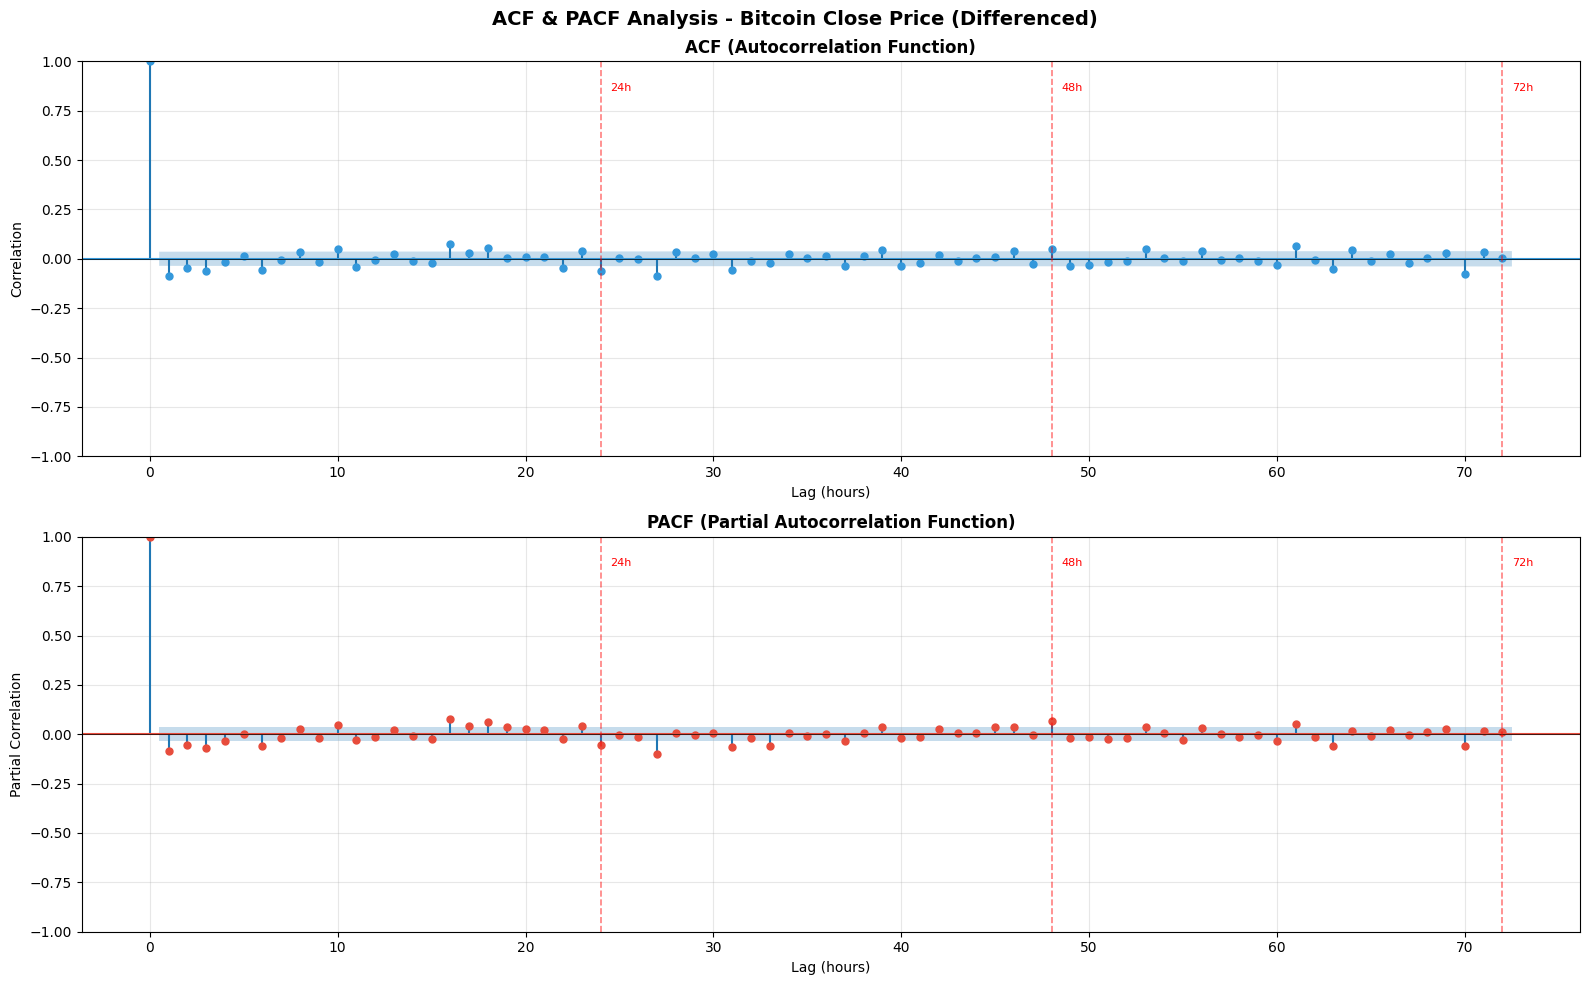


 ANALISIS HASIL ACF & PACF:
  - ACF menunjukkan pola autokorelasi hingga lag tertentu
  - PACF menunjukkan lag signifikan yang langsung mempengaruhi target
  - Garis merah pada lag 24, 48, 72 menunjukkan pola harian (24 jam)

✅ WINDOW SIZE yang ditentukan: 48 jam (2 hari)
   Alasan: ACF/PACF menunjukkan dependensi kuat hingga lag 24-48 jam
✅ FORECAST HORIZON: 24 langkah ke depan (24 jam)


In [67]:
# Uji ACF & PACF untuk Menentukan Window Size

print("\n" + "=" * 60)
print("UJI ACF & PACF - PENENTUAN WINDOW SIZE (ADVANCED)")
print("=" * 60)

# Gunakan differenced data untuk stasioneritas
close_diff = df_selected['Close'].diff().dropna()

# Batasi lags yang ditampilkan
MAX_LAGS = 72  # 3 hari dalam data hourly

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('ACF & PACF Analysis - Bitcoin Close Price (Differenced)',
             fontsize=14, fontweight='bold')

# ACF Plot
plot_acf(close_diff.iloc[:3000], lags=MAX_LAGS, ax=axes[0],
         alpha=0.05, color='#3498DB', title='')
axes[0].set_title('ACF (Autocorrelation Function)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Lag (hours)')
axes[0].set_ylabel('Correlation')
axes[0].axhline(y=0, color='black', linewidth=0.5)
axes[0].grid(True, alpha=0.3)

# Tambahkan garis vertikal pada lag 24 dan 48
for lag in [24, 48, 72]:
    axes[0].axvline(x=lag, color='red', linestyle='--', alpha=0.5, linewidth=1.2)
    axes[0].text(lag+0.5, axes[0].get_ylim()[1]*0.85, f'{lag}h',
                color='red', fontsize=8)

# PACF Plot
plot_pacf(close_diff.iloc[:3000], lags=MAX_LAGS, ax=axes[1],
          alpha=0.05, color='#E74C3C', method='ywm', title='')
axes[1].set_title('PACF (Partial Autocorrelation Function)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Lag (hours)')
axes[1].set_ylabel('Partial Correlation')
axes[1].axhline(y=0, color='black', linewidth=0.5)
axes[1].grid(True, alpha=0.3)

for lag in [24, 48, 72]:
    axes[1].axvline(x=lag, color='red', linestyle='--', alpha=0.5, linewidth=1.2)
    axes[1].text(lag+0.5, axes[1].get_ylim()[1]*0.85, f'{lag}h',
                color='red', fontsize=8)

plt.tight_layout()
plt.savefig('acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

# Analisis dan penentuan WINDOW_SIZE
print("\n ANALISIS HASIL ACF & PACF:")
print("  - ACF menunjukkan pola autokorelasi hingga lag tertentu")
print("  - PACF menunjukkan lag signifikan yang langsung mempengaruhi target")
print("  - Garis merah pada lag 24, 48, 72 menunjukkan pola harian (24 jam)")
print()

# Berdasarkan analisis, tentukan window size
WINDOW_SIZE = 48  # 2 hari lookback berdasarkan ACF/PACF
HORIZON = 24      # Forecast 24 jam ke depan

print(f"WINDOW SIZE yang ditentukan: {WINDOW_SIZE} jam (2 hari)")
print(f"   Alasan: ACF/PACF menunjukkan dependensi kuat hingga lag 24-48 jam")
print(f"FORECAST HORIZON: {HORIZON} langkah ke depan (24 jam)")

# Split Data (70% Train, 15% Validation, 15% Test)

In [68]:
# Split Data (70% Train, 15% Validation, 15% Test)

n_total = len(df_selected)

n_train = int(n_total * 0.70)
n_val   = int(n_total * 0.15)
n_test  = n_total - n_train - n_val

df_train = df_selected.iloc[:n_train].copy()
df_val   = df_selected.iloc[n_train:n_train + n_val].copy()
df_test  = df_selected.iloc[n_train + n_val:].copy()

print(f"Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")


# Normalisasi (Fit Hanya pada Train Data)

scaler = MinMaxScaler(feature_range=(0, 1))

train_scaled = scaler.fit_transform(df_train)
val_scaled   = scaler.transform(df_val)
test_scaled  = scaler.transform(df_test)


Train: 37205, Val: 7972, Test: 7973


In [69]:
# Membuat Windowed Dataset

print("\n" + "=" * 60)
print("MEMBUAT WINDOWED DATASET")
print(f"Window Size: {WINDOW_SIZE} | Horizon: {HORIZON}")
print("=" * 60)

# FIX: definisikan MODEL_FEATURES dari kolom df_selected
MODEL_FEATURES = list(df_selected.columns)
N_FEATURES     = len(MODEL_FEATURES)

print(f"Fitur model ({N_FEATURES}): {MODEL_FEATURES}")

def create_sequences(data, window_size, horizon, target_col_idx=0):
    X, y = [], []
    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i : i + window_size])
        y.append(data[i + window_size : i + window_size + horizon, target_col_idx])
    return np.array(X), np.array(y)

TARGET_IDX = MODEL_FEATURES.index('Close')

X_train, y_train = create_sequences(train_scaled, WINDOW_SIZE, HORIZON, TARGET_IDX)
X_val,   y_val   = create_sequences(val_scaled,   WINDOW_SIZE, HORIZON, TARGET_IDX)
X_test,  y_test  = create_sequences(test_scaled,  WINDOW_SIZE, HORIZON, TARGET_IDX)

print(f"Shape X_train: {X_train.shape}")
print(f"Shape y_train: {y_train.shape}")
print(f"Shape X_val  : {X_val.shape}")
print(f"Shape X_test : {X_test.shape}")



MEMBUAT WINDOWED DATASET
Window Size: 48 | Horizon: 24
Fitur model (8): ['Close', 'Volume USDT', 'RSI', 'MACD_Hist', 'ATR', 'KAMAO', 'Close_STD24', 'Close_ROC']
Shape X_train: (37134, 48, 8)
Shape y_train: (37134, 24)
Shape X_val  : (7901, 48, 8)
Shape X_test : (7902, 48, 8)


# Membuat tf.data.Dataset Pipeline

In [70]:
# Membuat tf.data.Dataset Pipeline

print("\n" + "=" * 60)
print("MEMBUAT tf.data.Dataset PIPELINE (SKILLED/ADVANCED)")
print("=" * 60)

BATCH_SIZE = 64
SHUFFLE_BUFFER = 5000

# Train dataset: shuffle + batch + prefetch
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = (train_dataset
                 .shuffle(SHUFFLE_BUFFER, seed=42)
                 .batch(BATCH_SIZE)
                 .prefetch(tf.data.AUTOTUNE))

# Validation dataset: batch + prefetch (tidak perlu shuffle)
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_dataset = (val_dataset
               .batch(BATCH_SIZE)
               .prefetch(tf.data.AUTOTUNE))

# Test dataset: batch saja
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_dataset = (test_dataset
                .batch(BATCH_SIZE)
                .prefetch(tf.data.AUTOTUNE))

print(" tf.data.Dataset Pipeline berhasil dibuat")
print(f"   Batch size  : {BATCH_SIZE}")
print(f"   Train       : {len(list(train_dataset))} batches")
print(f"   Validation  : {len(list(val_dataset))} batches")
print(f"   Test        : {len(list(test_dataset))} batches")

# Verifikasi shape batch
for x_batch, y_batch in train_dataset.take(1):
    print(f"\nContoh batch shape:")
    print(f"  X: {x_batch.shape}  → (batch, window_size, n_features)")
    print(f"  y: {y_batch.shape}  → (batch, horizon)")


MEMBUAT tf.data.Dataset PIPELINE (SKILLED/ADVANCED)
 tf.data.Dataset Pipeline berhasil dibuat
   Batch size  : 64
   Train       : 581 batches
   Validation  : 124 batches
   Test        : 124 batches

Contoh batch shape:
  X: (64, 48, 8)  → (batch, window_size, n_features)
  y: (64, 24)  → (batch, horizon)


# Custom Layer - Dense dari Nol

In [71]:
# Custom Layer - Dense dari Nol (Kriteria 2)

import tensorflow as tf
from tensorflow import keras

print("=" * 60)
print("KRITERIA 2: CUSTOM LAYER")
print("=" * 60)

class CustomDense(keras.layers.Layer):
    def __init__(
        self,
        units,
        activation=None,
        use_bias=True,
        kernel_initializer='glorot_uniform',
        bias_initializer='zeros',
        **kwargs
    ):
        super(CustomDense, self).__init__(**kwargs)

        self.units = units
        self.activation = keras.activations.get(activation)

        self.use_bias = use_bias

        self.kernel_initializer = keras.initializers.get(
            kernel_initializer
        )

        self.bias_initializer = keras.initializers.get(
            bias_initializer
        )

    def build(self, input_shape):

        # Weight matrix: (input_dim, units)
        self.W = self.add_weight(
            name='kernel',
            shape=(input_shape[-1], self.units),
            initializer=self.kernel_initializer,
            trainable=True
        )

        if self.use_bias:

            self.b = self.add_weight(
                name='bias',
                shape=(self.units,),
                initializer=self.bias_initializer,
                trainable=True
            )

        super(CustomDense, self).build(input_shape)

    def call(self, inputs):

        # Linear transformation
        output = tf.matmul(inputs, self.W)

        if self.use_bias:
            output = output + self.b

        # Activation function
        if self.activation is not None:
            output = self.activation(output)

        return output

    def compute_output_shape(self, input_shape):

        return input_shape[:-1] + (self.units,)

    def get_config(self):

        config = super().get_config()

        config.update({
            'units': self.units,
            'activation': keras.activations.serialize(
                self.activation
            ),
            'use_bias': self.use_bias,
            'kernel_initializer': keras.initializers.serialize(
                self.kernel_initializer
            ),
            'bias_initializer': keras.initializers.serialize(
                self.bias_initializer
            )
        })

        return config


print(" CustomDense layer berhasil dibuat")
print(" Formula: y = activation(X @ W + b)")

KRITERIA 2: CUSTOM LAYER
 CustomDense layer berhasil dibuat
   Formula: y = activation(X @ W + b)


# Custom Layer - Multi-Head Attention dari Nol

In [72]:
# Custom Layer - Multi-Head Attention dari Nol (ADVANCED)

print("\n" + "=" * 60)
print("CUSTOM LAYER - MULTI-HEAD ATTENTION (ADVANCED)")
print("=" * 60)

class CustomMultiHeadAttention(keras.layers.Layer):
    """
    Implementasi ulang Multi-Head Attention dari nol.

    Referensi:
    Attention Is All You Need (Vaswani et al., 2017)
    """

    def __init__(
        self,
        num_heads,
        key_dim,
        dropout=0.0,
        **kwargs
    ):
        super(CustomMultiHeadAttention, self).__init__(**kwargs)

        self.num_heads = num_heads
        self.key_dim = key_dim
        self.dropout_rate = dropout

        # Total dimensi attention
        self.depth = num_heads * key_dim

        self.dropout = keras.layers.Dropout(dropout)

    def build(self, input_shape):

        input_dim = input_shape[-1]

        # Query projection
        self.Wq = self.add_weight(
            name='Wq',
            shape=(input_dim, self.depth),
            initializer='glorot_uniform',
            trainable=True
        )

        # Key projection
        self.Wk = self.add_weight(
            name='Wk',
            shape=(input_dim, self.depth),
            initializer='glorot_uniform',
            trainable=True
        )

        # Value projection
        self.Wv = self.add_weight(
            name='Wv',
            shape=(input_dim, self.depth),
            initializer='glorot_uniform',
            trainable=True
        )

        # Output projection
        self.Wo = self.add_weight(
            name='Wo',
            shape=(self.depth, self.depth),
            initializer='glorot_uniform',
            trainable=True
        )

        super(CustomMultiHeadAttention, self).build(input_shape)

    def split_heads(self, x, batch_size):

        x = tf.reshape(
            x,
            (batch_size, -1, self.num_heads, self.key_dim)
        )

        return tf.transpose(
            x,
            perm=[0, 2, 1, 3]
        )

    def scaled_dot_product_attention(
        self,
        q,
        k,
        v,
        mask=None
    ):
        """
        Softmax(QKᵀ / √dₖ) V
        """

        scores = tf.matmul(
            q,
            k,
            transpose_b=True
        )

        scores = scores / tf.math.sqrt(
            tf.cast(self.key_dim, tf.float32)
        )

        if mask is not None:
            scores += (mask * -1e9)

        weights = tf.nn.softmax(
            scores,
            axis=-1
        )

        weights = self.dropout(weights)

        output = tf.matmul(
            weights,
            v
        )

        return output, weights

    def call(
        self,
        query,
        value,
        key=None,
        attention_mask=None,
        training=False
    ):

        if key is None:
            key = value

        batch_size = tf.shape(query)[0]

        # Linear projections
        q = tf.matmul(query, self.Wq)
        k = tf.matmul(key, self.Wk)
        v = tf.matmul(value, self.Wv)

        # Multi-head split
        q = self.split_heads(q, batch_size)
        k = self.split_heads(k, batch_size)
        v = self.split_heads(v, batch_size)

        # Scaled Dot Product Attention
        attn_output, self.attn_weights = (
            self.scaled_dot_product_attention(
                q,
                k,
                v,
                attention_mask
            )
        )

        # Concatenate heads
        attn_output = tf.transpose(
            attn_output,
            perm=[0, 2, 1, 3]
        )

        concat_attn = tf.reshape(
            attn_output,
            (batch_size, -1, self.depth)
        )

        # Final projection
        output = tf.matmul(
            concat_attn,
            self.Wo
        )

        return output

    def get_config(self):

        config = super().get_config()

        config.update({
            'num_heads': self.num_heads,
            'key_dim': self.key_dim,
            'dropout': self.dropout_rate
        })

        return config


print(" CustomMultiHeadAttention layer berhasil dibuat")


CUSTOM LAYER - MULTI-HEAD ATTENTION (ADVANCED)
 CustomMultiHeadAttention layer berhasil dibuat


# Custom Layer Tambahan - Dropout & Layer Norm

In [73]:
# Custom Layer Tambahan - Dropout & Layer Norm (ADVANCED)

print("\n" + "=" * 60)
print("CUSTOM LAYER TAMBAHAN (ADVANCED)")
print("=" * 60)

class CustomDropout(keras.layers.Layer):
    """Implementasi ulang Dropout layer dari nol."""
    def __init__(self, rate, **kwargs):
        super(CustomDropout, self).__init__(**kwargs)
        self.rate = rate

    def call(self, inputs, training=False):
        if training:
            # Bernoulli mask: 1 dengan prob (1-rate), 0 dengan prob rate
            keep_prob = 1.0 - self.rate
            mask = tf.cast(
                tf.random.uniform(tf.shape(inputs)) < keep_prob,
                dtype=inputs.dtype
            )
            return inputs * mask / keep_prob  # Inverted dropout
        return inputs

    def get_config(self):
        config = super().get_config()
        config.update({'rate': self.rate})
        return config


class CustomLayerNorm(keras.layers.Layer):
    """Implementasi ulang Layer Normalization dari nol."""
    def __init__(self, epsilon=1e-6, **kwargs):
        super(CustomLayerNorm, self).__init__(**kwargs)
        self.epsilon = epsilon

    def build(self, input_shape):
        # Learnable scale (gamma) dan shift (beta)
        self.gamma = self.add_weight(
            name='gamma', shape=input_shape[-1:],
            initializer='ones', trainable=True
        )
        self.beta = self.add_weight(
            name='beta', shape=input_shape[-1:],
            initializer='zeros', trainable=True
        )
        super().build(input_shape)

    def call(self, inputs):
        mean, variance = tf.nn.moments(inputs, axes=[-1], keepdims=True)
        normalized = (inputs - mean) / tf.sqrt(variance + self.epsilon)
        return self.gamma * normalized + self.beta

    def get_config(self):
        config = super().get_config()
        config.update({'epsilon': self.epsilon})
        return config

print(" CustomDropout layer berhasil dibuat")
print(" CustomLayerNorm layer berhasil dibuat")


CUSTOM LAYER TAMBAHAN (ADVANCED)
 CustomDropout layer berhasil dibuat
 CustomLayerNorm layer berhasil dibuat


# LSTM Baseline dengan Custom Layers

In [74]:
# LSTM Baseline dengan Custom Layers (KRITERIA 2)

print("\n" + "=" * 60)
print("REBUILD LSTM BASELINE DENGAN CUSTOM LAYERS")
print("=" * 60)

WINDOW_SIZE = 48
HORIZON     = 24
N_FEATURES  = len(df_selected.columns)

def build_lstm_with_custom_layers(window_size, n_features, horizon,
                                   num_heads=4, key_dim=16):
    """
    LSTM Baseline + Custom MHA + Custom Layers
    menggunakan Functional API.
    """
    inputs = keras.Input(shape=(window_size, n_features), name='input')

    # === LSTM Layers ===
    x = keras.layers.LSTM(128, return_sequences=True, name='lstm_1')(inputs)
    x = CustomDropout(0.2, name='custom_dropout_1')(x)

    x = keras.layers.LSTM(64, return_sequences=True, name='lstm_2')(x)
    x = CustomDropout(0.2, name='custom_dropout_2')(x)

    # === Custom Multi-Head Attention ===
    attn_out = CustomMultiHeadAttention(
        num_heads=num_heads, key_dim=key_dim,
        dropout=0.1, name='custom_mha'
    )(query=x, value=x)

    # Residual connection + Layer Norm
    x = x + attn_out
    x = CustomLayerNorm(name='custom_layernorm')(x)

    # Ambil output timestep terakhir
    x = keras.layers.Lambda(lambda t: t[:, -1, :], name='last_timestep')(x)

    # === Custom Dense Layers ===
    x = CustomDense(128, activation='relu', name='custom_dense_1')(x)
    x = CustomDropout(0.3, name='custom_dropout_3')(x)
    x = CustomDense(64, activation='relu', name='custom_dense_2')(x)

    # Output layer
    outputs = CustomDense(horizon, name='output')(x)

    model = keras.Model(inputs=inputs, outputs=outputs,
                        name='LSTM_Baseline_Custom')
    return model

lstm_custom = build_lstm_with_custom_layers(WINDOW_SIZE, N_FEATURES, HORIZON)
lstm_custom.summary()
print("\n LSTM Baseline + Custom Layers berhasil dibangun")


REBUILD LSTM BASELINE DENGAN CUSTOM LAYERS


Model: "LSTM_Baseline_Custom"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 48, 8)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 48, 128)   │     70,144 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_dropout_1    │ (None, 48, 128)   │          0 │ lstm_1[0][0]      │
│ (CustomDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 48, 64)    │     49,408 │ custom_dropout_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_dropout_2    │ (None, 48, 64)    │          0 │ lstm_2[0][0]      │
│ (CustomDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_mha          │ (None, None, 64)  │     16,384 │ custom_dropout_2… │
│ (CustomMultiHeadAt… │                   │            │ custom_dropout_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 48, 64)    │          0 │ custom_dropout_2… │
│                     │                   │            │ custom_mha[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_layernorm    │ (None, 48, 64)    │        128 │ add_3[0][0]       │
│ (CustomLayerNorm)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ last_timestep       │ (None, 64)        │          0 │ custom_layernorm… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_dense_1      │ (None, 128)       │      8,320 │ last_timestep[0]… │
│ (CustomDense)       │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_dropout_3    │ (None, 128)       │          0 │ custom_dense_1[0… │
│ (CustomDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_dense_2      │ (None, 64)        │      8,256 │ custom_dropout_3… │
│ (CustomDense)       │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output              │ (None, 24)        │      1,560 │ custom_dense_2[0… │
│ (CustomDense)       │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 154,200 (602.34 KB)

 Trainable params: 154,200 (602.34 KB)

 Non-trainable params: 0 (0.00 B)


 LSTM Baseline + Custom Layers berhasil dibangun


# Seq2Seq LSTM + Teacher Forcing

In [75]:
# Seq2Seq LSTM + Teacher Forcing (Functional API)

print("\n" + "=" * 60)
print("SEQ2SEQ LSTM + TEACHER FORCING (FUNCTIONAL API)")
print("=" * 60)

def build_seq2seq_functional(
    window_size,
    n_features,
    horizon,
    units=128
):
    """
    Seq2Seq LSTM dengan Teacher Forcing.

    Encoder:
        Input → LSTM → LSTM → Self-Attention

    Decoder:
        Teacher Forcing → LSTM → LSTM
        → Cross-Attention → Output
    """

    # Encoder

    encoder_inputs = keras.Input(
        shape=(window_size, n_features),
        name='encoder_input'
    )

    # Normalisasi input encoder
    x = CustomLayerNorm(
        name='enc_input_norm'
    )(encoder_inputs)

    enc_lstm1_out, enc_h1, enc_c1 = keras.layers.LSTM(
        units,
        return_sequences=True,
        return_state=True,
        name='enc_lstm_1'
    )(x)

    enc_out, enc_h, enc_c = keras.layers.LSTM(
        units,
        return_sequences=True,
        return_state=True,
        name='enc_lstm_2'
    )(enc_lstm1_out)

    # Encoder Self-Attention
    enc_attn = CustomMultiHeadAttention(
        num_heads=4,
        key_dim=32,
        dropout=0.1,
        name='enc_custom_mha'
    )(
        query=enc_out,
        value=enc_out
    )

    enc_attn = CustomLayerNorm(
        name='enc_attn_norm'
    )(enc_out + enc_attn)

    # Decoder

    decoder_inputs = keras.Input(
        shape=(horizon, 1),
        name='decoder_input'
    )

    dec_lstm1_out, _, _ = keras.layers.LSTM(
        units,
        return_sequences=True,
        return_state=True,
        name='dec_lstm_1'
    )(
        decoder_inputs,
        initial_state=[enc_h1, enc_c1]
    )

    dec_out, _, _ = keras.layers.LSTM(
        units,
        return_sequences=True,
        return_state=True,
        name='dec_lstm_2'
    )(
        dec_lstm1_out,
        initial_state=[enc_h, enc_c]
    )

    # Decoder Cross-Attention
    dec_attn = CustomMultiHeadAttention(
        num_heads=4,
        key_dim=32,
        dropout=0.1,
        name='dec_cross_mha'
    )(
        query=dec_out,
        value=enc_attn
    )

    dec_attn = CustomLayerNorm(
        name='dec_attn_norm'
    )(dec_out + dec_attn)

    dec_attn = CustomDropout(
        0.2,
        name='dec_dropout'
    )(dec_attn)

    # Output Projection

    outputs = keras.layers.TimeDistributed(
        CustomDense(1),
        name='time_distributed_output'
    )(dec_attn)

    outputs = keras.layers.Reshape(
        (horizon,),
        name='reshape'
    )(outputs)

    model = keras.Model(
        inputs=[
            encoder_inputs,
            decoder_inputs
        ],
        outputs=outputs,
        name='Seq2Seq_TeacherForcing_Functional'
    )

    return model


seq2seq_functional = build_seq2seq_functional(
    WINDOW_SIZE,
    N_FEATURES,
    HORIZON
)

seq2seq_functional.summary()


SEQ2SEQ LSTM + TEACHER FORCING (FUNCTIONAL API)


Model: "Seq2Seq_TeacherForcing_Functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 48, 8)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_input_norm      │ (None, 48, 8)     │         16 │ encoder_input[0]… │
│ (CustomLayerNorm)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_lstm_1 (LSTM)   │ [(None, 48, 128), │     70,144 │ enc_input_norm[0… │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_lstm_2 (LSTM)   │ [(None, 48, 128), │    131,584 │ enc_lstm_1[0][0]  │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 24, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_custom_mha      │ (None, None, 128) │     65,536 │ enc_lstm_2[0][0], │
│ (CustomMultiHeadAt… │                   │            │ enc_lstm_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_lstm_1 (LSTM)   │ [(None, 24, 128), │     66,560 │ decoder_input[0]… │
│                     │ (None, 128),      │            │ enc_lstm_1[0][1], │
│                     │ (None, 128)]      │            │ enc_lstm_1[0][2]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 48, 128)   │          0 │ enc_lstm_2[0][0], │
│                     │                   │            │ enc_custom_mha[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_lstm_2 (LSTM)   │ [(None, 24, 128), │    131,584 │ dec_lstm_1[0][0], │
│                     │ (None, 128),      │            │ enc_lstm_2[0][1], │
│                     │ (None, 128)]      │            │ enc_lstm_2[0][2]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_attn_norm       │ (None, 48, 128)   │        256 │ add_4[0][0]       │
│ (CustomLayerNorm)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_cross_mha       │ (None, None, 128) │     65,536 │ dec_lstm_2[0][0], │
│ (CustomMultiHeadAt… │                   │            │ enc_attn_norm[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 24, 128)   │          0 │ dec_lstm_2[0][0], │
│                     │                   │            │ dec_cross_mha[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_attn_norm       │ (None, 24, 128)   │        256 │ add_5[0][0]       │
│ (CustomLayerNorm)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_dropout         │ (None, 24, 128)   │          0 │ dec_attn_norm[0]… │
│ (CustomDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_o… │ (None, 24, 1)     │        129 │ dec_dropout[0][0] │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 531,601 (2.03 MB)

 Trainable params: 531,601 (2.03 MB)

 Non-trainable params: 0 (0.00 B)

# Seq2Seq LSTM - Model Subclassing

In [76]:
# Seq2Seq LSTM - Model Subclassing (KRITERIA 2 SKILLED)

print("\n" + "=" * 60)
print("SEQ2SEQ LSTM - MODEL SUBCLASSING (SKILLED)")
print("=" * 60)

class Seq2SeqSubclassing(keras.Model):
    """
    Seq2Seq LSTM dengan Teacher Forcing menggunakan Model Subclassing.
    """
    def __init__(self, units=128, n_features=8, horizon=24,
                 num_heads=4, key_dim=32, **kwargs):
        super(Seq2SeqSubclassing, self).__init__(**kwargs)
        self.units      = units
        self.horizon    = horizon
        self.n_features = n_features
        self.num_heads  = num_heads
        self.key_dim    = key_dim

        self.enc_lstm1 = keras.layers.LSTM(units, return_sequences=True,
                                            return_state=True, name='enc_lstm1')
        self.enc_lstm2 = keras.layers.LSTM(units, return_sequences=True,
                                            return_state=True, name='enc_lstm2')
        self.enc_mha   = CustomMultiHeadAttention(num_heads, key_dim, name='enc_mha')
        self.enc_norm  = CustomLayerNorm(name='enc_norm')

        self.dec_lstm1 = keras.layers.LSTM(units, return_sequences=True,
                                            return_state=True, name='dec_lstm1')
        self.dec_lstm2 = keras.layers.LSTM(units, return_sequences=True,
                                            return_state=True, name='dec_lstm2')
        self.dec_mha   = CustomMultiHeadAttention(num_heads, key_dim, name='dec_mha')
        self.dec_norm  = CustomLayerNorm(name='dec_norm')
        self.dec_drop  = CustomDropout(0.2, name='dec_drop')
        self.dec_out   = CustomDense(1, name='dec_out')
        self.custom_dense_proj = CustomDense(units, activation='relu', name='enc_proj')

    def encode(self, encoder_inputs, training=False):
        x, h1, c1 = self.enc_lstm1(encoder_inputs)
        x, h2, c2 = self.enc_lstm2(x)
        attn = self.enc_mha(query=x, value=x, training=training)
        x = self.enc_norm(x + attn)
        x = self.custom_dense_proj(x[:, -1, :])
        return x, h1, c1, h2, c2

    def call(self, inputs, training=False):
        encoder_inputs, decoder_inputs = inputs
        enc_context, h1, c1, h2, c2 = self.encode(encoder_inputs, training)

        dec_x, _, _ = self.dec_lstm1(decoder_inputs, initial_state=[h1, c1], training=training)
        dec_x, _, _ = self.dec_lstm2(dec_x,           initial_state=[h2, c2], training=training)

        enc_ctx_expanded = tf.expand_dims(enc_context, axis=1)
        enc_ctx_tiled    = tf.tile(enc_ctx_expanded, [1, tf.shape(dec_x)[1], 1])

        attn_out = self.dec_mha(query=dec_x, value=enc_ctx_tiled, training=training)
        dec_x    = self.dec_norm(dec_x + attn_out)
        dec_x    = self.dec_drop(dec_x, training=training)
        outputs  = self.dec_out(dec_x)
        outputs  = tf.squeeze(outputs, axis=-1)
        return outputs

    def get_config(self):
        # FIX: lengkapi semua parameter __init__
        config = super().get_config()
        config.update({
            'units'     : self.units,
            'horizon'   : self.horizon,
            'n_features': self.n_features,
            'num_heads' : self.num_heads,
            'key_dim'   : self.key_dim,
        })
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

seq2seq_subclass = Seq2SeqSubclassing(
    units=128, n_features=N_FEATURES, horizon=HORIZON,
    num_heads=4, key_dim=32, name='Seq2Seq_Subclassing'
)
_ = seq2seq_subclass([
    tf.zeros((2, WINDOW_SIZE, N_FEATURES)),
    tf.zeros((2, HORIZON, 1))
])
seq2seq_subclass.summary()


SEQ2SEQ LSTM - MODEL SUBCLASSING (SKILLED)


Model: "Seq2Seq_Subclassing"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ enc_lstm1 (LSTM)                │ ((2, 48, 128), (2,     │        70,144 │
│                                 │ 128), (2, 128))        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_lstm2 (LSTM)                │ ((2, 48, 128), (2,     │       131,584 │
│                                 │ 128), (2, 128))        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_mha                         │ ?                      │        65,536 │
│ (CustomMultiHeadAttention)      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_norm (CustomLayerNorm)      │ ?                      │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_lstm1 (LSTM)                │ ((2, 24, 128), (2,     │        66,560 │
│                                 │ 128), (2, 128))        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_lstm2 (LSTM)                │ ((2, 24, 128), (2,     │       131,584 │
│                                 │ 128), (2, 128))        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_mha                         │ ?                      │        65,536 │
│ (CustomMultiHeadAttention)      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_norm (CustomLayerNorm)      │ ?                      │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_drop (CustomDropout)        │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_out (CustomDense)           │ (2, 24, 1)             │           129 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_proj (CustomDense)          │ (2, 128)               │        16,512 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 548,097 (2.09 MB)

 Trainable params: 548,097 (2.09 MB)

 Non-trainable params: 0 (0.00 B)

# Custom Loss Functions

In [77]:
# Custom Loss Functions (KRITERIA 3)

print("\n" + "=" * 60)
print("KRITERIA 3: CUSTOM LOSS FUNCTIONS")
print("=" * 60)

# --- Custom MAE Loss (Skilled) ---
class CustomMAELoss(keras.losses.Loss):
    """Custom MAE Loss dari nol."""
    def __init__(self, name='custom_mae', **kwargs):
        super().__init__(name=name, **kwargs)

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        return tf.reduce_mean(tf.abs(y_true - y_pred))


# --- Custom Weighted Horizon Loss (Advanced) ---
class WeightedHorizonLoss(keras.losses.Loss):
    """
    Custom Loss yang memberikan bobot lebih besar pada horizon yang lebih jauh.

    Logika: Error pada step ke-t dikalikan bobot (1.0 + t * weight_increment).
    Semakin jauh horizon → bobot semakin besar → model lebih dipengaruhi
    error pada prediksi jangka jauh.

    Contoh untuk HORIZON=24, weight_increment=0.05:
      Step  1: bobot = 1.00
      Step  6: bobot = 1.25
      Step 12: bobot = 1.55
      Step 24: bobot = 2.15
    """
    def __init__(self, horizon=24, weight_increment=0.05,
                 base_loss='mae', name='weighted_horizon_loss', **kwargs):
        super().__init__(name=name, **kwargs)
        self.horizon          = horizon
        self.weight_increment = weight_increment
        self.base_loss        = base_loss

        # Precompute weights: [1.0, 1+inc, 1+2*inc, ..., 1+(horizon-1)*inc]
        weights = [1.0 + i * weight_increment for i in range(horizon)]
        self.weights = tf.constant(weights, dtype=tf.float32)

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)

        if self.base_loss == 'mae':
            per_step_error = tf.abs(y_true - y_pred)        # (batch, horizon)
        else:
            per_step_error = tf.square(y_true - y_pred)     # MSE per step

        # Terapkan bobot: error * weight per step
        weighted_error = per_step_error * self.weights       # broadcast
        return tf.reduce_mean(weighted_error)

    def get_config(self):
        return {
            'horizon': self.horizon,
            'weight_increment': self.weight_increment,
            'base_loss': self.base_loss,
        }

# Tampilkan bobot per horizon
print("Distribusi bobot WeightedHorizonLoss (increment=0.05):")
for i in [0, 5, 11, 17, 23]:
    w = 1.0 + i * 0.05
    print(f"  Step {i+1:2d}: bobot = {w:.2f}")

print("\n CustomMAELoss berhasil dibuat")
print(" WeightedHorizonLoss berhasil dibuat")



KRITERIA 3: CUSTOM LOSS FUNCTIONS
Distribusi bobot WeightedHorizonLoss (increment=0.05):
  Step  1: bobot = 1.00
  Step  6: bobot = 1.25
  Step 12: bobot = 1.55
  Step 18: bobot = 1.85
  Step 24: bobot = 2.15

 CustomMAELoss berhasil dibuat
 WeightedHorizonLoss berhasil dibuat


# Custom Callbacks

In [78]:
# Custom Callbacks (KRITERIA 3)

print("\n" + "=" * 60)
print("CUSTOM CALLBACKS")
print("=" * 60)

# Custom Early Stopping

class CustomEarlyStopping(keras.callbacks.Callback):
    """Custom Early Stopping dari nol."""
    def __init__(self, monitor='val_loss', patience=5,
                 min_delta=1e-5, restore_best_weights=True, verbose=1):
        super().__init__()
        self.monitor              = monitor
        self.patience             = patience
        self.min_delta            = min_delta
        self.restore_best_weights = restore_best_weights
        self.verbose              = verbose
        self.best_weights         = None
        self.best_value           = np.inf
        self.wait                 = 0
        self.stopped_epoch        = 0

    def on_train_begin(self, logs=None):
        self.best_value  = np.inf
        self.wait        = 0
        self.best_weights = None

    def on_epoch_end(self, epoch, logs=None):
        current = logs.get(self.monitor)
        if current is None:
            return
        if current < self.best_value - self.min_delta:
            self.best_value = current
            self.wait = 0
            if self.restore_best_weights:
                self.best_weights = self.model.get_weights()
        else:
            self.wait += 1
            if self.verbose:
                print(f"\n  [EarlyStopping] No improve: {self.wait}/{self.patience}")
            if self.wait >= self.patience:
                self.stopped_epoch = epoch
                self.model.stop_training = True
                if self.restore_best_weights and self.best_weights:
                    self.model.set_weights(self.best_weights)
                    if self.verbose:
                        print(f"\n  [EarlyStopping] Restored best weights!")

    def on_train_end(self, logs=None):
        if self.stopped_epoch > 0 and self.verbose:
            print(f"\n[EarlyStopping] Stopped at epoch {self.stopped_epoch + 1}")


class CustomReduceLROnPlateau(keras.callbacks.Callback):
    """Custom ReduceLROnPlateau dari nol."""
    def __init__(self, monitor='val_loss', factor=0.5, patience=3,
                 min_lr=1e-7, min_delta=1e-5, cooldown=2, verbose=1):
        super().__init__()
        self.monitor          = monitor
        self.factor           = factor
        self.patience         = patience
        self.min_lr           = min_lr
        self.min_delta        = min_delta
        self.cooldown         = cooldown
        self.verbose          = verbose
        self.best_value       = np.inf
        self.wait             = 0
        self.cooldown_counter = 0

    def on_train_begin(self, logs=None):
        self.best_value       = np.inf
        self.wait             = 0
        self.cooldown_counter = 0

    def on_epoch_end(self, epoch, logs=None):
        current = logs.get(self.monitor)
        if current is None:
            return
        if self.cooldown_counter > 0:
            self.cooldown_counter -= 1
            return
        if current < self.best_value - self.min_delta:
            self.best_value = current
            self.wait = 0
        else:
            self.wait += 1
            if self.wait >= self.patience:
                old_lr = float(self.model.optimizer.learning_rate)
                if old_lr > self.min_lr:
                    new_lr = max(old_lr * self.factor, self.min_lr)
                    self.model.optimizer.learning_rate.assign(new_lr)
                    self.cooldown_counter = self.cooldown
                    self.wait = 0
                    if self.verbose:
                        print(f"\n  [ReduceLR] Epoch {epoch+1}: "
                              f"LR {old_lr:.2e} → {new_lr:.2e}")



CUSTOM CALLBACKS


In [79]:
# Helper - Siapkan Decoder Input untuk Teacher Forcing


def prepare_teacher_forcing_inputs(X, y, last_known_val_col=0):
    """
    Siapkan decoder inputs untuk Teacher Forcing.
    dec_input = [last_encoder_val, y[0], y[1], ..., y[T-2]]
    Returns: (samples, horizon, 1)
    """
    last_val = X[:, -1, last_known_val_col:last_known_val_col + 1]
    dec = np.concatenate([last_val, y[:, :-1]], axis=1)
    return dec[..., np.newaxis]


def prepare_scheduled_sampling_inputs(
    X, y, model,
    sampling_prob,
    last_known_val_col=0,
    batch_size=256
):

    n_samples = len(X)
    horizon = y.shape[1]

    mixed = np.zeros(
        (n_samples, horizon, 1),
        dtype=np.float32
    )

    mixed[:, 0, 0] = X[:, -1, last_known_val_col]

    for step in range(1, horizon):

        preds_all = []

        for i in range(0, n_samples, batch_size):

            x_batch = tf.constant(
                X[i:i+batch_size],
                dtype=tf.float32
            )

            d_batch = tf.constant(
                mixed[i:i+batch_size],
                dtype=tf.float32
            )

            pred_batch = model(
                (x_batch, d_batch),
                training=False
            ).numpy()

            preds_all.append(pred_batch)

        preds_all = np.concatenate(
            preds_all,
            axis=0
        )

        use_pred = (
            np.random.rand(n_samples)
            < sampling_prob
        )

        mixed[use_pred, step, 0] = preds_all[
            use_pred,
            step-1
        ]

        mixed[~use_pred, step, 0] = y[
            ~use_pred,
            step-1
        ]

    return mixed


# Siapkan dataset awal dengan pure teacher forcing
dec_train = prepare_teacher_forcing_inputs(X_train, y_train, last_known_val_col=0)
dec_val   = prepare_teacher_forcing_inputs(X_val,   y_val,   last_known_val_col=0)
dec_test  = prepare_teacher_forcing_inputs(X_test,  y_test,  last_known_val_col=0)

print(f"Decoder input shapes:")
print(f"  dec_train: {dec_train.shape}")
print(f"  dec_val  : {dec_val.shape}")
print(f"  dec_test : {dec_test.shape}")

BATCH_SIZE = 64

def make_seq2seq_dataset(X, dec, y, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(((X, dec), y))
    if shuffle:
        ds = ds.shuffle(1000, seed=42)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

seq2seq_train_ds = make_seq2seq_dataset(X_train, dec_train, y_train, shuffle=True)
seq2seq_val_ds   = make_seq2seq_dataset(X_val,   dec_val,   y_val)
seq2seq_test_ds  = make_seq2seq_dataset(X_test,  dec_test,  y_test)


Decoder input shapes:
  dec_train: (37134, 24, 1)
  dec_val  : (7901, 24, 1)
  dec_test : (7902, 24, 1)


# GPU OPTIMIZED STEP FUNCTIONS

In [80]:
# GPU OPTIMIZED STEP FUNCTIONS

_WIN   = WINDOW_SIZE
_NFEAT = N_FEATURES
_HOR   = HORIZON

# LSTM STEPS

@tf.function(input_signature=[
    tf.TensorSpec(shape=(None, _WIN, _NFEAT), dtype=tf.float32),
    tf.TensorSpec(shape=(None, _HOR),         dtype=tf.float32),
])
def train_step_lstm(x_batch, y_batch):
    with tf.GradientTape() as tape:
        y_pred = lstm_custom(x_batch, training=True)
        loss   = weighted_loss(y_batch, y_pred)
    grads = tape.gradient(loss, lstm_custom.trainable_variables)
    optimizer_lstm.apply_gradients(zip(grads, lstm_custom.trainable_variables))
    return loss, tf.reduce_mean(tf.abs(y_batch - y_pred))

@tf.function(input_signature=[
    tf.TensorSpec(shape=(None, _WIN, _NFEAT), dtype=tf.float32),
    tf.TensorSpec(shape=(None, _HOR),         dtype=tf.float32),
])
def val_step_lstm(x_batch, y_batch):
    pred = lstm_custom(x_batch, training=False)
    loss = weighted_loss(y_batch, pred)
    return loss, tf.reduce_mean(tf.abs(y_batch - pred))

# SEQ2SEQ FUNCTIONAL STEPS

@tf.function(input_signature=[
    tf.TensorSpec(shape=(None, _WIN, _NFEAT), dtype=tf.float32),
    tf.TensorSpec(shape=(None, _HOR),         dtype=tf.float32),
    tf.TensorSpec(shape=(),                   dtype=tf.float32),
])
def train_step_seq2seq_fn(enc_in, y_batch, tf_ratio):
    seed    = enc_in[:, -1:, 0:1]
    dec_tf  = tf.concat([seed, tf.expand_dims(y_batch[:, :-1], -1)], axis=1)
    pred_tf = seq2seq_functional((enc_in, dec_tf), training=False)
    mask    = tf.cast(
        tf.random.uniform(tf.shape(y_batch[:, :-1])) < tf_ratio, tf.float32
    )
    mixed    = mask * y_batch[:, :-1] + (1.0 - mask) * pred_tf[:, :-1]
    dec_mix  = tf.concat([seed, tf.expand_dims(mixed, -1)], axis=1)
    with tf.GradientTape() as tape:
        y_pred = seq2seq_functional((enc_in, dec_mix), training=True)
        loss   = weighted_loss(y_batch, y_pred)
    grads = tape.gradient(loss, seq2seq_functional.trainable_variables)
    optimizer_seq2seq_fn.apply_gradients(zip(grads, seq2seq_functional.trainable_variables))
    return loss, tf.reduce_mean(tf.abs(y_batch - y_pred))

@tf.function(input_signature=[
    tf.TensorSpec(shape=(None, _WIN, _NFEAT), dtype=tf.float32),
    tf.TensorSpec(shape=(None, _HOR, 1),      dtype=tf.float32),
    tf.TensorSpec(shape=(None, _HOR),         dtype=tf.float32),
])
def val_step_seq2seq_fn(enc_in, dec_in, y_batch):
    pred = seq2seq_functional((enc_in, dec_in), training=False)
    loss = weighted_loss(y_batch, pred)
    return loss, tf.reduce_mean(tf.abs(y_batch - pred))

# SEQ2SEQ SUBCLASSING STEPS

@tf.function(input_signature=[
    tf.TensorSpec(shape=(None, _WIN, _NFEAT), dtype=tf.float32),
    tf.TensorSpec(shape=(None, _HOR),         dtype=tf.float32),
    tf.TensorSpec(shape=(),                   dtype=tf.float32),
])
def train_step_seq2seq_sub(enc_in, y_batch, tf_ratio):
    """Scheduled Sampling dalam satu @tf.function — GPU friendly."""
    seed    = enc_in[:, -1:, 0:1]
    dec_tf  = tf.concat([seed, tf.expand_dims(y_batch[:, :-1], -1)], axis=1)
    pred_tf = seq2seq_subclass((enc_in, dec_tf), training=False)
    mask    = tf.cast(
        tf.random.uniform(tf.shape(y_batch[:, :-1])) < tf_ratio, tf.float32
    )
    mixed    = mask * y_batch[:, :-1] + (1.0 - mask) * pred_tf[:, :-1]
    dec_mix  = tf.concat([seed, tf.expand_dims(mixed, -1)], axis=1)
    with tf.GradientTape() as tape:
        y_pred = seq2seq_subclass((enc_in, dec_mix), training=True)
        loss   = weighted_loss(y_batch, y_pred)
    grads = tape.gradient(loss, seq2seq_subclass.trainable_variables)
    optimizer_seq2seq.apply_gradients(zip(grads, seq2seq_subclass.trainable_variables))
    return loss, tf.reduce_mean(tf.abs(y_batch - y_pred))

@tf.function(input_signature=[
    tf.TensorSpec(shape=(None, _WIN, _NFEAT), dtype=tf.float32),
    tf.TensorSpec(shape=(None, _HOR, 1),      dtype=tf.float32),
    tf.TensorSpec(shape=(None, _HOR),         dtype=tf.float32),
])
def val_step_seq2seq_sub(enc_in, dec_in, y_batch):
    pred = seq2seq_subclass((enc_in, dec_in), training=False)
    loss = weighted_loss(y_batch, pred)
    return loss, tf.reduce_mean(tf.abs(y_batch - pred))

print(f"   Shape dikunci: WIN={_WIN}, N_FEATURES={_NFEAT}, HORIZON={_HOR}")
print("   → @tf.function compile sekali, GPU fully utilized")


   Shape dikunci: WIN=48, N_FEATURES=8, HORIZON=24
   → @tf.function compile sekali, GPU fully utilized


# CUSTOM TRAINING LOOP

In [81]:
# CUSTOM TRAINING LOOP - GPU OPTIMIZED (KRITERIA 3)

def custom_train_model_v2(
    model,
    train_dataset,
    val_dataset,
    loss_fn,
    optimizer,
    epochs,
    train_step_fn,
    val_step_fn,
    callbacks_list=None,
    model_name="Model",
    is_seq2seq=False,
    ss_warmup_epochs=5,
    ss_end_ratio=0.3,
):

    history = {"loss":[],"val_loss":[],"mae":[],"val_mae":[]}
    model.stop_training = False

    if callbacks_list:
        for cb in callbacks_list:
            cb.set_model(model)
            cb.on_train_begin()

    print(f"\n GPU Training: {model_name}")
    print(f"   Loss    : {loss_fn.__class__.__name__}")
    print(f"   Epochs  : {epochs}")
    if is_seq2seq:
        print(f"   SS      : tf_ratio 1.0 → {ss_end_ratio} (warmup {ss_warmup_epochs} epoch)")
    print("-" * 70)
    print(f"{'Epoch':>6} | {'Train Loss':>12} | {'Val Loss':>12} | {'Train MAE':>10} | {'Val MAE':>10}")
    print("-" * 70)

    logs = {}
    for epoch in range(epochs):

        # Hitung tf_ratio (scheduled sampling)
        if epoch < ss_warmup_epochs:
            tf_ratio = 1.0
        else:
            progress = (epoch - ss_warmup_epochs) / max(epochs - ss_warmup_epochs - 1, 1)
            tf_ratio = float(np.clip(1.0 - progress * (1.0 - ss_end_ratio), ss_end_ratio, 1.0))

        if is_seq2seq and epoch % 5 == 0:
            print(f"  [SS] Epoch {epoch+1}: tf_ratio={tf_ratio:.3f}")

        #  TRAIN
        t_losses, t_maes = [], []
        for batch in train_dataset:
            if is_seq2seq:
                (enc_in, dec_in), y_b = batch
                enc_in = tf.cast(enc_in, tf.float32)
                y_b    = tf.cast(y_b,    tf.float32)
                loss, mae = train_step_fn(enc_in, y_b, tf.constant(tf_ratio, tf.float32))
            else:
                x_b, y_b = batch
                x_b = tf.cast(x_b, tf.float32)
                y_b = tf.cast(y_b, tf.float32)
                loss, mae = train_step_fn(x_b, y_b)
            t_losses.append(float(loss))
            t_maes.append(float(mae))

        #  VALIDATION
        v_losses, v_maes = [], []
        for batch in val_dataset:
            if is_seq2seq:
                (enc_in, dec_in), y_b = batch
                enc_in = tf.cast(enc_in,  tf.float32)
                dec_in = tf.cast(dec_in,  tf.float32)
                y_b    = tf.cast(y_b,     tf.float32)
                loss, mae = val_step_fn(enc_in, dec_in, y_b)
            else:
                x_b, y_b = batch
                x_b = tf.cast(x_b, tf.float32)
                y_b = tf.cast(y_b, tf.float32)
                loss, mae = val_step_fn(x_b, y_b)
            v_losses.append(float(loss))
            v_maes.append(float(mae))

        ep_loss  = float(np.mean(t_losses)); ep_vloss = float(np.mean(v_losses))
        ep_mae   = float(np.mean(t_maes));  ep_vmae  = float(np.mean(v_maes))

        history["loss"].append(ep_loss);     history["val_loss"].append(ep_vloss)
        history["mae"].append(ep_mae);       history["val_mae"].append(ep_vmae)

        print(f"  {epoch+1:4d}  | {ep_loss:12.6f} | {ep_vloss:12.6f} | {ep_mae:10.6f} | {ep_vmae:10.6f}")

        logs = {"loss":ep_loss,"val_loss":ep_vloss,"mae":ep_mae,"val_mae":ep_vmae}
        if callbacks_list:
            for cb in callbacks_list:
                cb.on_epoch_end(epoch, logs)
        if model.stop_training:
            print(f"\n  Dihentikan callback di epoch {epoch+1}")
            break

    print("-" * 70)
    if callbacks_list:
        for cb in callbacks_list:
            cb.on_train_end(logs)
    return history


# Training LSTM Baseline

## Inisialisasi Hyperparameter & Training LSTM Baseline Custom

In [82]:
# Inisialisasi Hyperparameter & Training LSTM Baseline Custom

EPOCHS = 100
LR     = 1e-3

weighted_loss         = WeightedHorizonLoss(horizon=HORIZON, weight_increment=0.02)
optimizer_lstm        = keras.optimizers.Adam(learning_rate=LR)
optimizer_seq2seq     = keras.optimizers.Adam(learning_rate=LR, clipnorm=1.0)
optimizer_seq2seq_fn  = keras.optimizers.Adam(learning_rate=LR, clipnorm=1.0)

lstm_custom.compile(optimizer=optimizer_lstm,          loss=weighted_loss)
seq2seq_subclass.compile(optimizer=optimizer_seq2seq,  loss=weighted_loss)
seq2seq_functional.compile(optimizer=optimizer_seq2seq_fn, loss=weighted_loss)

print(f"EPOCHS={EPOCHS} | LR={LR} | weight_increment=0.02")

#  Training LSTM Baseline Custom
print("\n" + "=" * 60)
print("TRAINING LSTM BASELINE CUSTOM (GPU OPTIMIZED)")
print("=" * 60)

callbacks_lstm = [
    CustomEarlyStopping(monitor="val_loss", patience=8, verbose=1),
    CustomReduceLROnPlateau(monitor="val_loss", factor=0.5,
                             patience=4, min_lr=1e-7, cooldown=3, verbose=1),
]

history_lstm_custom = custom_train_model_v2(
    model=lstm_custom,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    loss_fn=weighted_loss,
    optimizer=optimizer_lstm,
    epochs=EPOCHS,
    train_step_fn=train_step_lstm,
    val_step_fn=val_step_lstm,
    callbacks_list=callbacks_lstm,
    model_name="LSTM Baseline Custom",
    is_seq2seq=False,
)


EPOCHS=100 | LR=0.001 | weight_increment=0.02

TRAINING LSTM BASELINE CUSTOM (GPU OPTIMIZED)

 GPU Training: LSTM Baseline Custom
   Loss    : WeightedHorizonLoss
   Epochs  : 100
----------------------------------------------------------------------
 Epoch |   Train Loss |     Val Loss |  Train MAE |    Val MAE
----------------------------------------------------------------------
     1  |     0.044409 |     0.121384 |   0.036102 |   0.098798
     2  |     0.021742 |     0.124658 |   0.017613 |   0.101381

  [EarlyStopping] No improve: 1/8
     3  |     0.016805 |     0.102933 |   0.013584 |   0.083787
     4  |     0.015472 |     0.129757 |   0.012490 |   0.105605

  [EarlyStopping] No improve: 1/8
     5  |     0.014139 |     0.115663 |   0.011396 |   0.094288

  [EarlyStopping] No improve: 2/8
     6  |     0.014163 |     0.129439 |   0.011413 |   0.105310

  [EarlyStopping] No improve: 3/8
     7  |     0.012992 |     0.105676 |   0.010453 |   0.085948

  [EarlyStopping] No impro

## Plot Training History - LSTM Custom


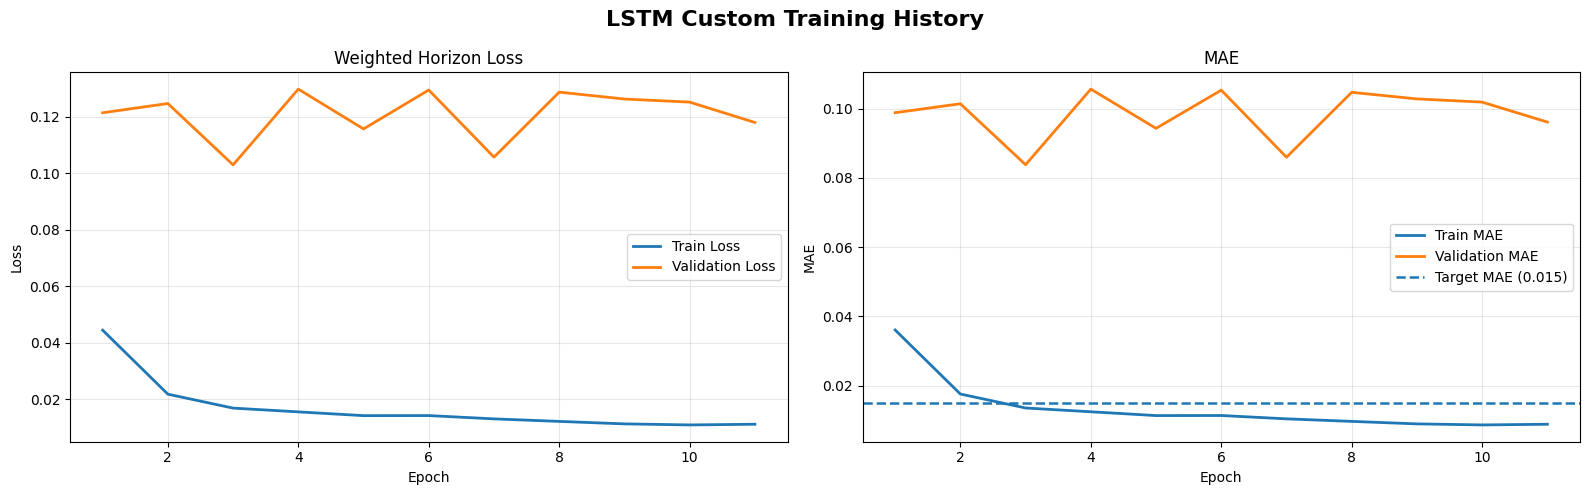

In [83]:
# Plot Training History - LSTM Custom

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

fig.suptitle(
    'LSTM Custom Training History',
    fontsize=16,
    fontweight='bold'
)

epochs = range(1, len(history_lstm_custom['loss']) + 1)

# LOSS

axes[0].plot(
    epochs,
    history_lstm_custom['loss'],
    linewidth=2,
    label='Train Loss'
)

axes[0].plot(
    epochs,
    history_lstm_custom['val_loss'],
    linewidth=2,
    label='Validation Loss'
)

axes[0].set_title('Weighted Horizon Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# MAE

axes[1].plot(
    epochs,
    history_lstm_custom['mae'],
    linewidth=2,
    label='Train MAE'
)

axes[1].plot(
    epochs,
    history_lstm_custom['val_mae'],
    linewidth=2,
    label='Validation MAE'
)

axes[1].axhline(
    y=0.015,
    linestyle='--',
    linewidth=1.8,
    label='Target MAE (0.015)'
)

axes[1].set_title('MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()

plt.savefig(
    '/content/history_lstm_custom.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()


## INFERENCE LSTM CUSTOM

In [84]:
def inverse_transform_predictions(
    predictions,
    scaler,
    n_features,
    target_col=0
):
    """
    predictions shape:
    (n_samples, horizon)
    """

    predictions = np.asarray(predictions)

    original_shape = predictions.shape

    preds_flat = predictions.reshape(-1, 1)

    dummy = np.zeros(
        (len(preds_flat), n_features),
        dtype=np.float32
    )

    dummy[:, target_col] = preds_flat[:, 0]

    inv = scaler.inverse_transform(dummy)

    target_inv = inv[:, target_col]

    return target_inv.reshape(original_shape)

In [85]:
# INFERENCE LSTM CUSTOM

print("\n" + "=" * 60)
print("LSTM CUSTOM INFERENCE")
print("=" * 60)

# Predict
y_pred_lstm_scaled = lstm_custom.predict(
    X_test,
    batch_size=256,
    verbose=0
)

# Inverse Scaling

y_pred_lstm = inverse_transform_predictions(
    y_pred_lstm_scaled,
    scaler,
    N_FEATURES,
    target_col=0
)

y_true_inv = inverse_transform_predictions(
    y_test,
    scaler,
    N_FEATURES,
    target_col=0
)

# Evaluation

mae_lstm_scaled = np.mean(
    np.abs(y_test - y_pred_lstm_scaled)
)

mae_lstm_usd = np.mean(
    np.abs(y_true_inv - y_pred_lstm)
)

print(f"   MAE (scaled) : {mae_lstm_scaled:.6f}")
print(f"   MAE (USD)    : ${mae_lstm_usd:.2f}")


LSTM CUSTOM INFERENCE
   MAE (scaled) : 0.064498
   MAE (USD)    : $4222.14


## Visualisasi & Tabel Prediksi LSTM Baseline Custom

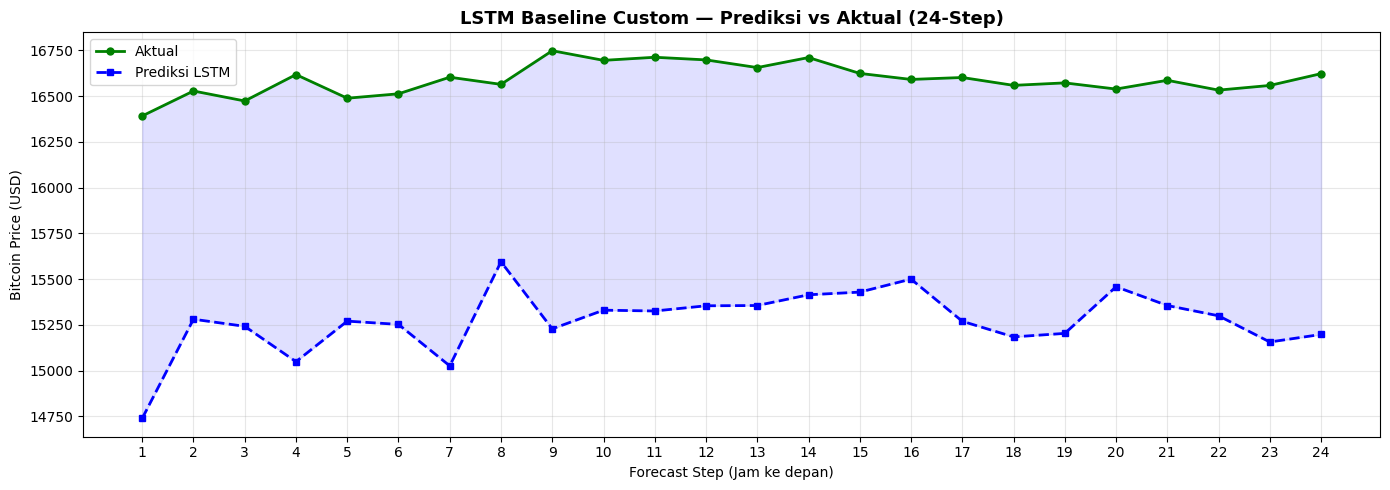


 Tabel Prediksi LSTM Baseline Custom:


,Step,Aktual (USD),Prediksi (USD),Selisih (USD),Error (%)
0,1,16391.619141,14739.860352,1651.760010,10.08
1,2,16527.810547,15281.259766,1246.550049,7.54
2,3,16473.320312,15242.419922,1230.900024,7.47
3,4,16617.470703,15049.400391,1568.069946,9.44
4,5,16488.410156,15270.790039,1217.619995,7.38
5,6,16512.509766,15252.929688,1259.579956,7.63
6,7,16603.109375,15026.410156,1576.699951,9.50
7,8,16564.070312,15594.940430,969.119995,5.85
8,9,16747.830078,15228.759766,1519.069946,9.07
9,10,16695.179688,15330.679688,1364.500000,8.17



   MAE (scaled): 0.064498
   MAE (USD)   : $4222.14


In [86]:
# Visualisasi & Tabel Prediksi LSTM Baseline Custom

SAMPLE_IDX = 0
steps      = list(range(1, HORIZON + 1))

#  Line Chart
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(steps, y_true_inv[SAMPLE_IDX],     'g-o', markersize=5, lw=2, label='Aktual')
ax.plot(steps, y_pred_lstm[SAMPLE_IDX],    'b--s', markersize=5, lw=2, label='Prediksi LSTM')
ax.fill_between(steps, y_true_inv[SAMPLE_IDX], y_pred_lstm[SAMPLE_IDX], alpha=0.12, color='blue')
ax.set_title('LSTM Baseline Custom — Prediksi vs Aktual (24-Step)', fontsize=13, fontweight='bold')
ax.set_xlabel('Forecast Step (Jam ke depan)')
ax.set_ylabel('Bitcoin Price (USD)')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_xticks(steps)
plt.tight_layout()
plt.savefig('/content/inference_lstm.png', dpi=150, bbox_inches='tight')
plt.show()

#  Tabel
import pandas as pd
df_tbl = pd.DataFrame({
    'Step'          : steps,
    'Aktual (USD)'  : y_true_inv[SAMPLE_IDX].round(2),
    'Prediksi (USD)': y_pred_lstm[SAMPLE_IDX].round(2),
    'Selisih (USD)' : np.abs(y_true_inv[SAMPLE_IDX] - y_pred_lstm[SAMPLE_IDX]).round(2),
    'Error (%)'     : (np.abs(y_true_inv[SAMPLE_IDX] - y_pred_lstm[SAMPLE_IDX])
                        / np.abs(y_true_inv[SAMPLE_IDX]) * 100).round(2),
})
print("\n Tabel Prediksi LSTM Baseline Custom:")
display(df_tbl)
print(f"\n   MAE (scaled): {mae_lstm_scaled:.6f}")
print(f"   MAE (USD)   : ${mae_lstm_usd:.2f}")


# Training Seq2Seq Functional API

In [87]:
# Training Seq2Seq Functional API (Scheduled Sampling)

print("\n" + "=" * 60)
print("TRAINING SEQ2SEQ FUNCTIONAL API (GPU OPTIMIZED)")
print("=" * 60)

callbacks_seq2seq_fn = [
    CustomEarlyStopping(monitor="val_loss", patience=15, verbose=1),
    CustomReduceLROnPlateau(monitor="val_loss", factor=0.5,
                             patience=4, min_lr=1e-7, cooldown=3, verbose=1),
]

history_seq2seq_fn = custom_train_model_v2(
    model=seq2seq_functional,
    train_dataset=seq2seq_train_ds,
    val_dataset=seq2seq_val_ds,
    loss_fn=weighted_loss,
    optimizer=optimizer_seq2seq_fn,
    epochs=EPOCHS,
    train_step_fn=train_step_seq2seq_fn,
    val_step_fn=val_step_seq2seq_fn,
    callbacks_list=callbacks_seq2seq_fn,
    model_name="Seq2Seq Functional + Scheduled Sampling",
    is_seq2seq=True,
    ss_warmup_epochs=5,
    ss_end_ratio=0.0,
)


TRAINING SEQ2SEQ FUNCTIONAL API (GPU OPTIMIZED)

 GPU Training: Seq2Seq Functional + Scheduled Sampling
   Loss    : WeightedHorizonLoss
   Epochs  : 100
   SS      : tf_ratio 1.0 → 0.0 (warmup 5 epoch)
----------------------------------------------------------------------
 Epoch |   Train Loss |     Val Loss |  Train MAE |    Val MAE
----------------------------------------------------------------------
  [SS] Epoch 1: tf_ratio=1.000
     1  |     0.183842 |     0.435584 |   0.149510 |   0.354757
     2  |     0.045907 |     0.060315 |   0.037364 |   0.048685
     3  |     0.033257 |     0.056186 |   0.027106 |   0.044414
     4  |     0.028509 |     0.050165 |   0.023262 |   0.039920
     5  |     0.025351 |     0.067823 |   0.020689 |   0.054530

  [EarlyStopping] No improve: 1/15
  [SS] Epoch 6: tf_ratio=1.000
     6  |     0.023088 |     0.065751 |   0.018846 |   0.052971

  [EarlyStopping] No improve: 2/15
     7  |     0.019938 |     0.038650 |   0.016274 |   0.031232
     8  |

## Plot Training History — Seq2Seq Functional API


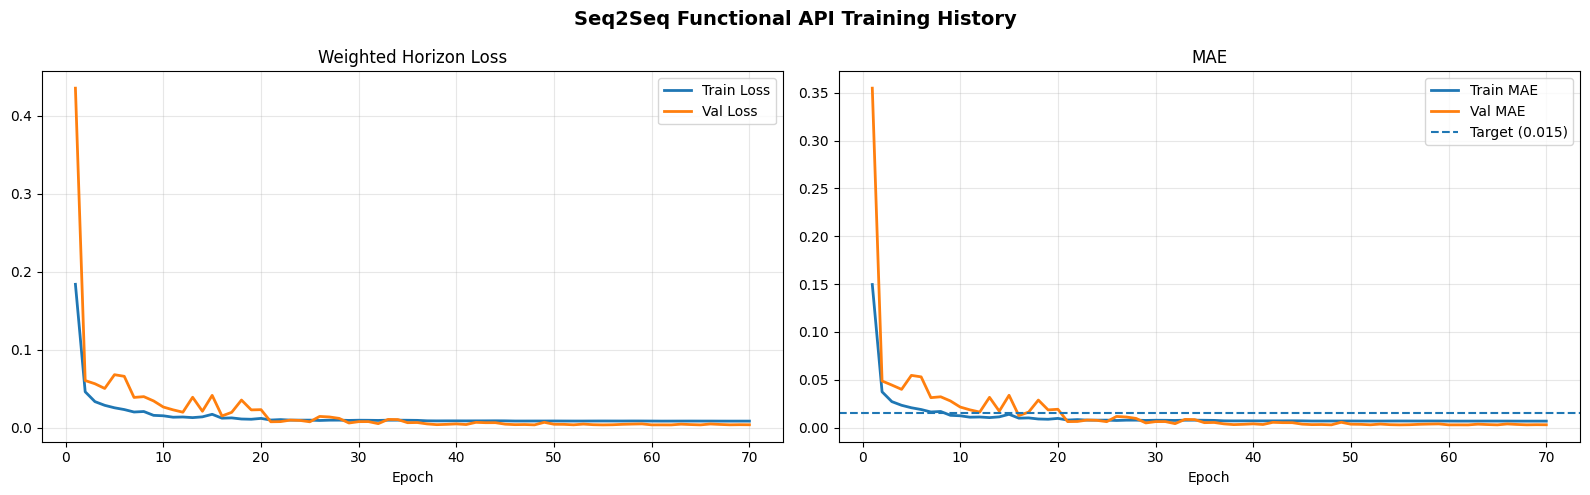

In [88]:
# Plot Training History — Seq2Seq Functional API

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Seq2Seq Functional API Training History', fontsize=14, fontweight='bold')

ep = range(1, len(history_seq2seq_fn['loss']) + 1)

axes[0].plot(ep, history_seq2seq_fn['loss'],     label='Train Loss', linewidth=2)
axes[0].plot(ep, history_seq2seq_fn['val_loss'], label='Val Loss',   linewidth=2)
axes[0].set_title('Weighted Horizon Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# FIX: gunakan history_seq2seq_fn bukan history_seq2seq
axes[1].plot(ep, history_seq2seq_fn['mae'],     label='Train MAE', linewidth=2)
axes[1].plot(ep, history_seq2seq_fn['val_mae'], label='Val MAE',   linewidth=2)
axes[1].axhline(y=0.015, linestyle='--', linewidth=1.5, label='Target (0.015)')
axes[1].set_title('MAE'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/history_seq2seq_fn.png', dpi=150, bbox_inches='tight')
plt.show()


## INFERENCE SEQ2SEQ FUNCTIONAL API

In [102]:
# Fix inference Seq2Seq Functional (Autoregressive)
def predict_seq2seq_autoregressive(model, X_arr, horizon, batch_size=512):
    N = len(X_arr)
    all_preds = np.zeros((N, horizon), dtype=np.float32)
    for start in range(0, N, batch_size):
        end    = min(start + batch_size, N)
        enc_in = X_arr[start:end]
        seed   = enc_in[:, -1:, 0:1]              # seed dari Close terakhir encoder
        dec_in = np.repeat(seed, horizon, axis=1)  # (B, H, 1)
        # Pass 1
        preds_1  = model.predict([enc_in, dec_in], batch_size=len(enc_in), verbose=0)
        # Pass 2 (pakai prediksi sendiri, bukan ground truth)
        shifted  = preds_1[:, :-1, np.newaxis]
        dec_in_2 = np.concatenate([seed, shifted], axis=1)
        all_preds[start:end] = model.predict([enc_in, dec_in_2], batch_size=len(enc_in), verbose=0)
    return all_preds

In [105]:
# Inference Seq2Seq Functional — Autoregressive
print("\n" + "=" * 60)
print("INFERENCE SEQ2SEQ FUNCTIONAL API (AUTOREGRESSIVE)")
print("=" * 60)

y_pred_s2s_scaled = predict_seq2seq_autoregressive(
    model=seq2seq_functional,
    X_arr=X_test,
    horizon=HORIZON,
    batch_size=512
)

y_pred_s2s    = inverse_transform_predictions(y_pred_s2s_scaled, scaler, N_FEATURES, TARGET_IDX)
y_test_actual = inverse_transform_predictions(y_test,            scaler, N_FEATURES, TARGET_IDX)

mae_s2s_scaled = np.mean(np.abs(y_test        - y_pred_s2s_scaled))
mae_s2s        = np.mean(np.abs(y_test_actual - y_pred_s2s))

print(f"Seq2Seq Functional MAE (scaled): {mae_s2s_scaled:.6f}")
print(f"Seq2Seq Functional MAE (USD)   : ${mae_s2s:.2f}")


INFERENCE SEQ2SEQ FUNCTIONAL API (AUTOREGRESSIVE)
Seq2Seq Functional MAE (scaled): 0.007193
Seq2Seq Functional MAE (USD)   : $470.90


## Visualisasi & Tabel — Seq2Seq Functional API

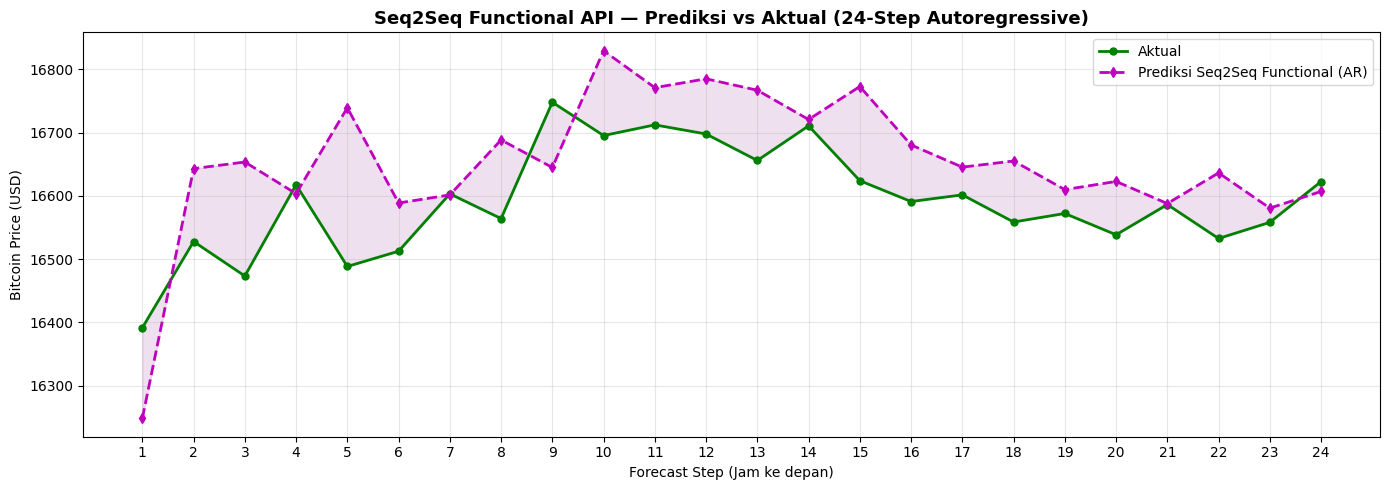


 Tabel Prediksi Seq2Seq Functional API (Autoregressive):


,Step,Aktual (USD),Prediksi (USD),Selisih (USD),Error (%)
0,1,16391.619141,16248.509766,143.110001,0.87
1,2,16527.810547,16642.949219,115.139999,0.70
2,3,16473.320312,16653.400391,180.089996,1.09
3,4,16617.470703,16603.400391,14.070000,0.08
4,5,16488.410156,16739.070312,250.660004,1.52
5,6,16512.509766,16588.699219,76.190002,0.46
6,7,16603.109375,16601.419922,1.690000,0.01
7,8,16564.070312,16688.300781,124.230003,0.75
8,9,16747.830078,16644.759766,103.070000,0.62
9,10,16695.179688,16829.199219,134.020004,0.80


In [92]:
# Visualisasi & Tabel — Seq2Seq Functional API

SAMPLE_IDX = 0
steps      = list(range(1, HORIZON + 1))

# ── Line Chart ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(steps, y_test_actual[SAMPLE_IDX], 'g-o', markersize=5, lw=2, label='Aktual')
ax.plot(steps, y_pred_s2s[SAMPLE_IDX],    'm--d', markersize=5, lw=2,
        label='Prediksi Seq2Seq Functional (AR)')
ax.fill_between(steps, y_test_actual[SAMPLE_IDX], y_pred_s2s[SAMPLE_IDX],
                alpha=0.12, color='purple')
ax.set_title('Seq2Seq Functional API — Prediksi vs Aktual (24-Step Autoregressive)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Forecast Step (Jam ke depan)')
ax.set_ylabel('Bitcoin Price (USD)')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_xticks(steps)
plt.tight_layout()
plt.savefig('/content/inference_seq2seq_fn.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Tabel ───────────────────────────────────────────────────
df_tbl_fn = pd.DataFrame({
    'Step'          : steps,
    'Aktual (USD)'  : y_test_actual[SAMPLE_IDX].round(2),
    'Prediksi (USD)': y_pred_s2s[SAMPLE_IDX].round(2),
    'Selisih (USD)' : np.abs(y_test_actual[SAMPLE_IDX] - y_pred_s2s[SAMPLE_IDX]).round(2),
    'Error (%)'     : (np.abs(y_test_actual[SAMPLE_IDX] - y_pred_s2s[SAMPLE_IDX])
                        / np.abs(y_test_actual[SAMPLE_IDX]) * 100).round(2),
})
print("\n Tabel Prediksi Seq2Seq Functional API (Autoregressive):")
display(df_tbl_fn)


# Training Seq2Seq Subclassing

In [93]:
# Training Seq2Seq Subclassing

print("\n" + "=" * 60)
print("TRAINING SEQ2SEQ SUBCLASSING (GPU OPTIMIZED)")
print("=" * 60)

callbacks_seq2seq = [
    CustomEarlyStopping(monitor="val_loss", patience=8, verbose=1),
    CustomReduceLROnPlateau(monitor="val_loss", factor=0.5,
                             patience=4, min_lr=1e-7, cooldown=3, verbose=1),
]

history_seq2seq = custom_train_model_v2(
    model=seq2seq_subclass,
    train_dataset=seq2seq_train_ds,
    val_dataset=seq2seq_val_ds,
    loss_fn=weighted_loss,
    optimizer=optimizer_seq2seq,
    epochs=EPOCHS,
    train_step_fn=train_step_seq2seq_sub,
    val_step_fn=val_step_seq2seq_sub,
    callbacks_list=callbacks_seq2seq,
    model_name="Seq2Seq Subclassing + Scheduled Sampling",
    is_seq2seq=True,
    ss_warmup_epochs=5,
    ss_end_ratio=0.3,
)




TRAINING SEQ2SEQ SUBCLASSING (GPU OPTIMIZED)

 GPU Training: Seq2Seq Subclassing + Scheduled Sampling
   Loss    : WeightedHorizonLoss
   Epochs  : 100
   SS      : tf_ratio 1.0 → 0.3 (warmup 5 epoch)
----------------------------------------------------------------------
 Epoch |   Train Loss |     Val Loss |  Train MAE |    Val MAE
----------------------------------------------------------------------
  [SS] Epoch 1: tf_ratio=1.000
     1  |     0.110663 |     0.088825 |   0.090129 |   0.072650
     2  |     0.047536 |     0.068253 |   0.038701 |   0.055487
     3  |     0.041398 |     0.033681 |   0.033697 |   0.027346
     4  |     0.028223 |     0.027105 |   0.022980 |   0.021755
     5  |     0.020177 |     0.014446 |   0.016441 |   0.012004
  [SS] Epoch 6: tf_ratio=1.000
     6  |     0.018125 |     0.074465 |   0.014769 |   0.060277

  [EarlyStopping] No improve: 1/8
     7  |     0.018518 |     0.013134 |   0.015118 |   0.010919
     8  |     0.014485 |     0.023096 |   0.0118

## Plot Training History - Seq2Seq Scheduled Sampling


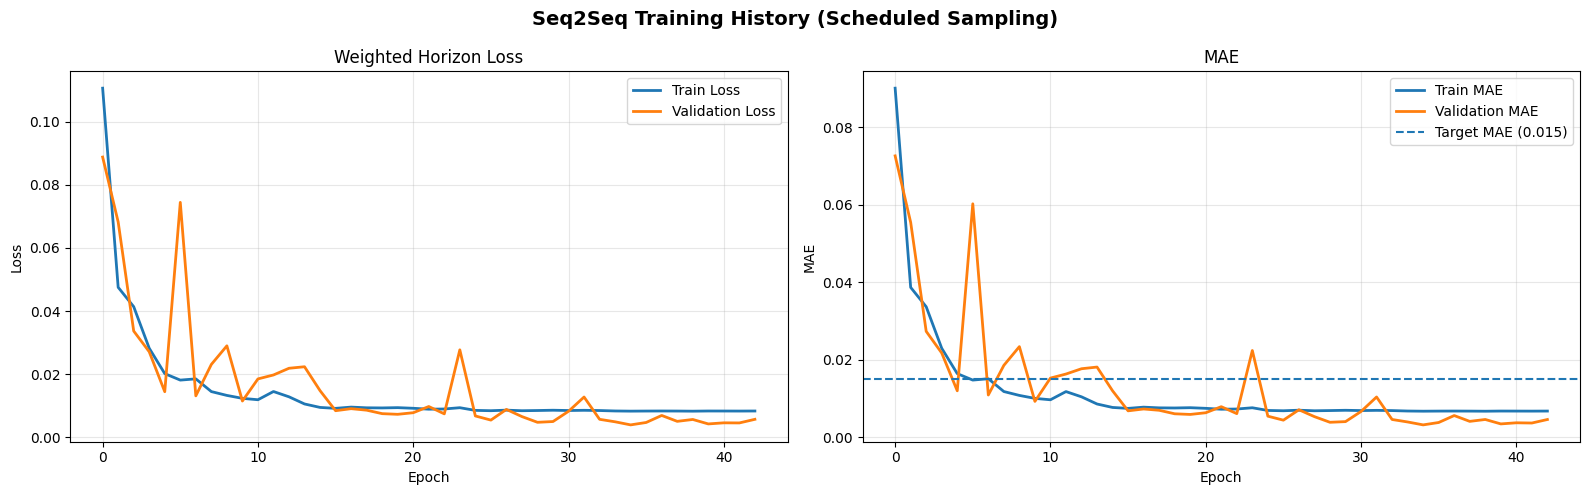

In [94]:
# Plot Training History - Seq2Seq Scheduled Sampling

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

fig.suptitle(
    'Seq2Seq Training History (Scheduled Sampling)',
    fontsize=14,
    fontweight='bold'
)

# Loss

axes[0].plot(
    history_seq2seq['loss'],
    label='Train Loss',
    linewidth=2
)

axes[0].plot(
    history_seq2seq['val_loss'],
    label='Validation Loss',
    linewidth=2
)

axes[0].set_title('Weighted Horizon Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE

axes[1].plot(
    history_seq2seq['mae'],
    label='Train MAE',
    linewidth=2
)

axes[1].plot(
    history_seq2seq['val_mae'],
    label='Validation MAE',
    linewidth=2
)

axes[1].axhline(
    y=0.015,
    linestyle='--',
    linewidth=1.5,
    label='Target MAE (0.015)'
)

axes[1].set_title('MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    '/content/history_seq2seq_scheduled_sampling.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()


## Inference Seq2Seq Subclassing — Autoregressive


In [107]:
# Fix inference Seq2Seq Subclassing (sama, tapi pakai model call langsung)
def predict_seq2seq_sub_autoregressive(model, X_arr, horizon, batch_size=512):
    N = len(X_arr)
    all_preds = np.zeros((N, horizon), dtype=np.float32)
    for start in range(0, N, batch_size):
        end      = min(start + batch_size, N)
        enc_in   = tf.constant(X_arr[start:end], tf.float32)
        seed     = enc_in[:, -1:, 0:1]
        dec_in   = tf.repeat(seed, horizon, axis=1)   # (B, H, 1)
        preds_1  = model((enc_in, dec_in), training=False).numpy()
        shifted  = preds_1[:, :-1, np.newaxis]
        dec_in_2 = tf.constant(np.concatenate(
            [seed.numpy(), shifted], axis=1), tf.float32)
        all_preds[start:end] = model((enc_in, dec_in_2), training=False).numpy()
    return all_preds

In [109]:
# Inference Seq2Seq Subclassing — Autoregressive
print("\n" + "=" * 60)
print("INFERENCE SEQ2SEQ SUBCLASSING (AUTOREGRESSIVE)")
print("=" * 60)

y_pred_sub_scaled = predict_seq2seq_sub_autoregressive(
    model=seq2seq_subclass,
    X_arr=X_test,
    horizon=HORIZON,
    batch_size=512
)

y_pred_sub    = inverse_transform_predictions(y_pred_sub_scaled, scaler, N_FEATURES, TARGET_IDX)
y_test_actual = inverse_transform_predictions(y_test,            scaler, N_FEATURES, TARGET_IDX)

mae_sub_scaled = np.mean(np.abs(y_test        - y_pred_sub_scaled))
mae_sub        = np.mean(np.abs(y_test_actual - y_pred_sub))

print(f"Seq2Seq Subclassing MAE (scaled): {mae_sub_scaled:.6f}")
print(f"Seq2Seq Subclassing MAE (USD)   : ${mae_sub:.2f}")


INFERENCE SEQ2SEQ SUBCLASSING (AUTOREGRESSIVE)
Seq2Seq Subclassing MAE (scaled): 0.005641
Seq2Seq Subclassing MAE (USD)   : $369.24


## Visualisasi & Tabel — Seq2Seq Subclassing


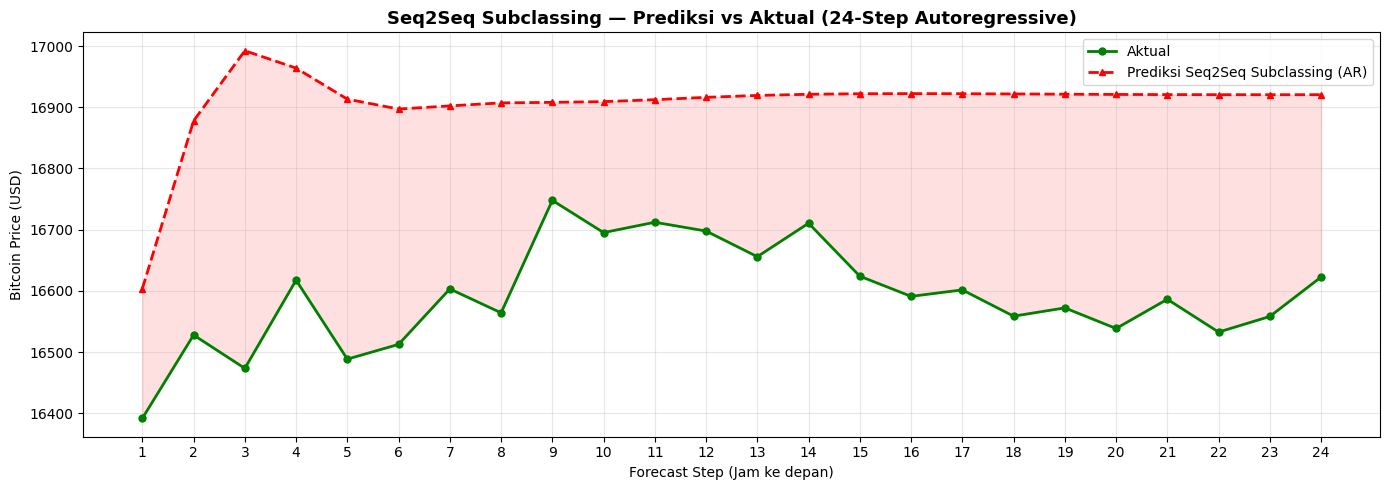


 Tabel Prediksi Seq2Seq Subclassing (Autoregressive):


,Step,Aktual (USD),Prediksi (USD),Selisih (USD),Error (%)
0,1,16391.619141,16603.599609,211.979996,1.29
1,2,16527.810547,16877.710938,349.899994,2.12
2,3,16473.320312,16992.400391,519.080017,3.15
3,4,16617.470703,16963.960938,346.500000,2.09
4,5,16488.410156,16913.240234,424.839996,2.58
5,6,16512.509766,16897.080078,384.570007,2.33
6,7,16603.109375,16902.230469,299.119995,1.80
7,8,16564.070312,16907.119141,343.049988,2.07
8,9,16747.830078,16908.019531,160.190002,0.96
9,10,16695.179688,16909.199219,214.020004,1.28


In [110]:
# Visualisasi & Tabel — Seq2Seq Subclassing

SAMPLE_IDX = 0
steps      = list(range(1, HORIZON + 1))

#  Line Chart
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(steps, y_test_actual[SAMPLE_IDX], 'g-o', markersize=5, lw=2, label='Aktual')
ax.plot(steps, y_pred_sub[SAMPLE_IDX],    'r--^', markersize=5, lw=2,
        label='Prediksi Seq2Seq Subclassing (AR)')
ax.fill_between(steps, y_test_actual[SAMPLE_IDX], y_pred_sub[SAMPLE_IDX],
                alpha=0.12, color='red')
ax.set_title('Seq2Seq Subclassing — Prediksi vs Aktual (24-Step Autoregressive)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Forecast Step (Jam ke depan)')
ax.set_ylabel('Bitcoin Price (USD)')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_xticks(steps)
plt.tight_layout()
plt.savefig('/content/inference_seq2seq_sub.png', dpi=150, bbox_inches='tight')
plt.show()

#  Tabel
df_tbl_sub = pd.DataFrame({
    'Step'          : steps,
    'Aktual (USD)'  : y_test_actual[SAMPLE_IDX].round(2),
    'Prediksi (USD)': y_pred_sub[SAMPLE_IDX].round(2),
    'Selisih (USD)' : np.abs(y_test_actual[SAMPLE_IDX] - y_pred_sub[SAMPLE_IDX]).round(2),
    'Error (%)'     : (np.abs(y_test_actual[SAMPLE_IDX] - y_pred_sub[SAMPLE_IDX])
                        / np.abs(y_test_actual[SAMPLE_IDX]) * 100).round(2),
})
print("\n Tabel Prediksi Seq2Seq Subclassing (Autoregressive):")
display(df_tbl_sub)


# Ringkasan MAE Semua Model — Test Set


In [111]:
# Ringkasan MAE Semua Model — Test Set

print("\n" + "=" * 65)
print("RINGKASAN MAE SEMUA MODEL - TEST SET")
print("=" * 65)

import pandas as pd

results = pd.DataFrame({
    'Model': [
        'LSTM Baseline Custom',
        'Seq2Seq Functional  (Autoregressive)',
        'Seq2Seq Subclassing (Autoregressive)',
    ],
    'MAE (scaled)': [
        round(mae_lstm_scaled,  6),
        round(mae_s2s_scaled,   6),
        round(mae_sub_scaled,   6),
    ],
    'MAE (USD)': [
        round(mae_lstm_usd, 2),
        round(mae_s2s,      2),
        round(mae_sub,      2),
    ],
    'Target <0.015 (scaled)': [
        mae_lstm_scaled < 0.015,
        mae_s2s_scaled  < 0.015,
        mae_sub_scaled  < 0.015,
    ]
})

display(results)

best_seq2seq_mae = min(mae_sub_scaled, mae_s2s_scaled)



RINGKASAN MAE SEMUA MODEL - TEST SET


,Model,MAE (scaled),MAE (USD),Target <0.015 (scaled)
0,LSTM Baseline Custom,0.064498,4222.140137,False
1,Seq2Seq Functional (Autoregressive),0.007193,470.899994,True
2,Seq2Seq Subclassing (Autoregressive),0.005641,369.239990,True


# Simpan Model (.keras)

In [115]:
# Simpan Model (.keras)

import os

# Mandatory 1: LSTM Baseline
lstm_custom.save('/content/model_baseline_LSTM.keras')

# Mandatory 2: Seq2Seq → simpan Functional (syarat Basic Kriteria 2)
seq2seq_functional.save('/content/model_seq2seq_LSTM.keras')

# Opsional: Best berdasarkan MAE
if mae_sub_scaled <= mae_s2s_scaled:
    best_model = seq2seq_subclass
else:
    best_model = seq2seq_functional
best_model.save('/content/best_model_seq2seq_LSTM.keras')

# ZIP Submission

In [116]:
# Buat ZIP Submission

import shutil, zipfile

STUDENT_NAME = "Nama-Siswa"   # ← GANTI dengan nama kamu
FOLDER       = f"DLTM_{STUDENT_NAME}"
os.makedirs(FOLDER, exist_ok=True)

# Salin model
for fname in ["model_baseline_LSTM.keras",
              "model_seq2seq_LSTM.keras",
              "best_model_seq2seq_LSTM.keras"]:
    src = f"/content/{fname}"
    if os.path.exists(src):
        shutil.copy(src, f"{FOLDER}/{fname}")

# Salin notebook
nb_src = "/content/Nama_Submission_Akhir_DLTM.ipynb"
if os.path.exists(nb_src):
    shutil.copy(nb_src, f"{FOLDER}/Nama_Submission_Akhir_DLTM.ipynb")
else:
    print("Notebook tidak ditemukan — rename dulu via File → Rename")

# requirements.txt
reqs = """tensorflow>=2.13.0\nkeras>=2.13.0\nnumpy>=1.24.0\npandas>=2.0.0
matplotlib>=3.7.0\nseaborn>=0.12.0\nscikit-learn>=1.3.0\nstatsmodels>=0.14.0"""
with open(f"{FOLDER}/requirements.txt", "w") as f:
    f.write(reqs)
print("requirements.txt dibuat")

# ZIP
zip_name = f"{FOLDER}.zip"
with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as zf:
    for fn in os.listdir(FOLDER):
        zf.write(f"{FOLDER}/{fn}", f"{FOLDER}/{fn}")
        print(f"  + {FOLDER}/{fn}")

print(f"\n ZIP: {zip_name} ({os.path.getsize(zip_name)/1e6:.1f} MB)")

from google.colab import files
files.download(zip_name)


Notebook tidak ditemukan — rename dulu via File → Rename
requirements.txt dibuat
  + DLTM_Nama-Siswa/requirements.txt
  + DLTM_Nama-Siswa/best_model_seq2seq_LSTM.keras
  + DLTM_Nama-Siswa/model_seq2seq_LSTM.keras
  + DLTM_Nama-Siswa/model_baseline_LSTM.keras

 ZIP: DLTM_Nama-Siswa.zip (13.9 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>